<a href="https://colab.research.google.com/github/aman-theanalyst/SwiftRoute-Logistic-Dashboard/blob/main/Pyhton_Insight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [209]:
"""
╔══════════════════════════════════════════════════════════════════════════════════╗
║         LOGISTIC ANALYTICS                  ║
║         Data Analyst Portfolio Project                                    ║
║                                                                                  ║
║  Dataset   : 27,979 orders · 55 drivers · 45 vehicles · 6 hubs                   ║
║  Scope     : EDA + Deep Dive Insights + Actionable Business Intelligence         ║
║  Output    : 15 publication-quality visualizations + printed insights report     ║
╚══════════════════════════════════════════════════════════════════════════════════╝

Author  : Aman Singh Negi
Version : 1.0.0 (Colab Edition)
"""

# ─────────────────────────────────────────────────────────────
#  GOOGLE COLAB SETUP & IMPORTS
# ─────────────────────────────────────────────────────────────
from google.colab import drive
import os
import sys
import argparse
import warnings
import textwrap
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# Mount Google Drive
drive.mount('/content/drive')

# UPDATE THIS PATH to point to the folder in your Drive containing the CSVs
DATA_DIR   = Path('/content/drive/MyDrive/SwiftBoard Logistic Dashboard/Data')
OUTPUT_DIR = Path('/content/drive/MyDrive/SwiftBoard Logistic Dashboard')

# Create output directory in the Colab instance
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [210]:
# ─────────────────────────────────────────────────────────────
#  CONFIGURATION & DESIGN SYSTEM
# ─────────────────────────────────────────────────────────────
PALETTE = {
    "bg":        "#0F0F14",
    "surface":   "#16161E",
    "surface2":  "#1E1E2A",
    "border":    "#2C2C3C",
    "text":      "#E8E6F0",
    "muted":     "#6E6C80",
    "red":       "#FF4757",
    "amber":     "#FFAA2B",
    "green":     "#00D084",
    "blue":      "#4F8EF7",
    "purple":    "#B57BEE",
    "teal":      "#00C9B1",
}

DIVERGING   = [PALETTE["red"], PALETTE["amber"], PALETTE["green"]]
SEQUENTIAL  = [PALETTE["surface2"], PALETTE["blue"]]
CAT_COLORS  = [PALETTE["blue"], PALETTE["green"], PALETTE["amber"],
               PALETTE["red"], PALETTE["purple"], PALETTE["teal"]]

FONT_FAMILY = "DejaVu Sans"
DPI         = 120 # Slightly lowered from 180 for better Colab inline rendering

def apply_dark_style():
    """Apply a consistent dark editorial theme to all matplotlib figures."""
    mpl.rcParams.update({
        "figure.facecolor":     PALETTE["bg"],
        "axes.facecolor":       PALETTE["surface"],
        "axes.edgecolor":       PALETTE["border"],
        "axes.labelcolor":      PALETTE["muted"],
        "axes.titlecolor":      PALETTE["text"],
        "axes.titlesize":       13,
        "axes.labelsize":       10,
        "axes.spines.top":      False,
        "axes.spines.right":    False,
        "axes.grid":            True,
        "grid.color":           PALETTE["border"],
        "grid.linestyle":       "--",
        "grid.linewidth":       0.5,
        "grid.alpha":           0.6,
        "xtick.color":          PALETTE["muted"],
        "ytick.color":          PALETTE["muted"],
        "xtick.labelsize":      9,
        "ytick.labelsize":      9,
        "legend.facecolor":     PALETTE["surface2"],
        "legend.edgecolor":     PALETTE["border"],
        "legend.labelcolor":    PALETTE["text"],
        "legend.fontsize":      9,
        "text.color":           PALETTE["text"],
        "font.family":          FONT_FAMILY,
        "figure.dpi":           DPI,
        "savefig.dpi":          DPI,
        "savefig.bbox":         "tight",
        "savefig.facecolor":    PALETTE["bg"],
    })

apply_dark_style()

In [211]:
# ─────────────────────────────────────────────────────────────
#  HELPERS & FORMATTING
# ─────────────────────────────────────────────────────────────
def fig_header(fig, title: str, subtitle: str, tag: str = "EDA", tag_color: str = None):
    tag_color = tag_color or PALETTE["blue"]
    fig.text(0.02, 0.98, tag, fontsize=8, fontweight="bold", color=tag_color,
             va="top", ha="left", transform=fig.transFigure,
             bbox=dict(boxstyle="round,pad=0.3", fc=PALETTE["surface2"], ec=tag_color, lw=1))
    fig.text(0.08, 0.982, title, fontsize=15, fontweight="bold", color=PALETTE["text"],
             va="top", ha="left", transform=fig.transFigure)
    fig.text(0.08, 0.963, subtitle, fontsize=9, color=PALETTE["muted"],
             va="top", ha="left", transform=fig.transFigure)
    fig.add_artist(mpl.lines.Line2D([0.02, 0.98], [0.952, 0.952],
                                    transform=fig.transFigure, color=PALETTE["border"], lw=0.8))

def save_fig(fig, name: str, output_dir: Path, show: bool = False):
    """Save figure to Colab output directory and display inline."""
    path = output_dir / f"{name}.png"
    fig.savefig(path)
    print(f"  ✓ Saved & Rendered → {path.name}")
    plt.show() # Forced to show in Colab
    plt.close(fig)

def section_banner(title: str, num: int = None):
    prefix = f"[{num:02d}] " if num else "    "
    bar = "─" * 70
    print(f"\n{bar}\n{prefix}{title.upper()}\n{bar}")

def insight_print(finding: str, implication: str, color_code: str = "⚡"):
    wrapper = textwrap.TextWrapper(width=68, initial_indent="     ", subsequent_indent="     ")
    print(f"\n  {color_code} FINDING")
    for line in wrapper.wrap(finding): print(line)
    print(f"\n  → IMPLICATION")
    for line in wrapper.wrap(implication): print(line)

In [212]:
# ─────────────────────────────────────────────────────────────
#  DATA LOADING & PREPROCESSING
# ─────────────────────────────────────────────────────────────
def load_data(data_dir: Path) -> dict[str, pd.DataFrame]:
    section_banner("DATA LOADING & PREPROCESSING")
    files = {"drivers": "Drivers.csv", "hubs": "Hubs.csv",
             "orders": "Orders.csv", "vehicles": "Vehicles.csv"}
    dfs = {}
    for key, fname in files.items():
        path = data_dir / fname
        if not path.exists():
            raise FileNotFoundError(f"Missing {fname}. Ensure '{data_dir}' contains the dataset.")

        df = pd.read_csv(path, encoding="utf-16", sep="\t")
        df.columns = df.columns.str.strip()
        dfs[key] = df
        print(f"  Loaded {fname:<20} → {df.shape[0]:>6,} rows × {df.shape[1]} cols")
    return dfs

def preprocess(dfs: dict) -> dict[str, pd.DataFrame]:
    # Drivers
    dr = dfs["drivers"].copy()
    dr["Hire Date"] = pd.to_datetime(dr["Hire Date"], dayfirst=True, errors="coerce")
    ref = pd.Timestamp("2024-12-01")
    dr["tenure_months"] = ((ref - dr["Hire Date"]).dt.days / 30).round(0)
    dr["tenure_band"] = pd.cut(dr["tenure_months"], bins=[0, 12, 24, 36, 48, 999],
                               labels=["<1 yr", "1–2 yr", "2–3 yr", "3–4 yr", "4+ yr"])
    # Vehicles
    veh = dfs["vehicles"].copy()
    veh["Purchase Date"] = pd.to_datetime(veh["Purchase Date"], dayfirst=True, errors="coerce")
    veh["age_years"] = ((ref - veh["Purchase Date"]).dt.days / 365).round(2)
    veh["age_band"] = pd.cut(veh["age_years"], bins=[0, 2, 4, 6, 99],
                             labels=["0–2 yr", "2–4 yr", "4–6 yr", "6+ yr"])
    # Orders
    ord_ = dfs["orders"].copy()
    ord_["Order Date"]          = pd.to_datetime(ord_["Order Date"], dayfirst=True, errors="coerce")
    ord_["Actual Delivery Date"] = pd.to_datetime(ord_["Actual Delivery Date"], dayfirst=True, errors="coerce")
    ord_["year_month"]           = ord_["Order Date"].dt.to_period("M")

    # Merge and Bin
    ord_ = ord_.merge(dr[["DriverID", "Employment Type", "Performance Rating",
                          "Experience Years", "tenure_months", "tenure_band"]],
                      left_on="Driver ID", right_on="DriverID", how="left")
    ord_["hub_proc_q"] = pd.qcut(ord_["Hub Processing Time Hours"], q=4,
                                 labels=["Q1 Fastest", "Q2", "Q3", "Q4 Slowest"])
    ord_["delivery_band"] = pd.cut(ord_["Delivery Time Hours"],
                                   bins=[0, 6, 12, 24, 36, 48, 60, 72, 9999],
                                   labels=["0–6 h", "6–12 h", "12–24 h", "24–36 h",
                                           "36–48 h", "48–60 h", "60–72 h", "72 h+"])
    ord_["exp_band"] = pd.cut(ord_["Experience Years"], bins=[0, 2, 4, 6, 8, 99],
                              labels=["0–2 yr", "2–4 yr", "4–6 yr", "6–8 yr", "8+ yr"])

    dfs["drivers"], dfs["vehicles"], dfs["orders"] = dr, veh, ord_

    print(f"\n  Post-processing summary:")
    print(f"  Delay rate        : {ord_['Is Delayed'].mean() * 100:.2f}%")
    print(f"  Avg delivery time : {ord_['Delivery Time Hours'].mean():.2f} hrs")
    print(f"  Avg CSAT          : {ord_['Customer Satisfaction Score'].mean():.3f} / 5")
    return dfs

# Execute Loading
dfs = load_data(DATA_DIR)
dfs = preprocess(dfs)


──────────────────────────────────────────────────────────────────────
    DATA LOADING & PREPROCESSING
──────────────────────────────────────────────────────────────────────
  Loaded Drivers.csv          →     55 rows × 6 cols
  Loaded Hubs.csv             →      6 rows × 3 cols
  Loaded Orders.csv           → 27,979 rows × 15 cols
  Loaded Vehicles.csv         →     45 rows × 7 cols

  Post-processing summary:
  Delay rate        : 21.12%
  Avg delivery time : 35.78 hrs
  Avg CSAT          : 4.169 / 5


In [213]:
# ═════════════════════════════════════════════════════════════
#  SECTION 3 ── COMMAND-LINE OVERVIEW (printed stats)
# ═════════════════════════════════════════════════════════════

def print_eda_overview(dfs: dict):
    """Print a comprehensive EDA overview to the terminal."""
    section_banner("EXPLORATORY DATA ANALYSIS — OVERVIEW")

    ord_ = dfs["orders"]
    veh  = dfs["vehicles"]
    dr   = dfs["drivers"]

    print("\n  ── ORDERS ──────────────────────────────────────────")
    print(ord_[["Is Delayed", "Is On Time", "Delivery Time Hours",
                "Hub Processing Time Hours",
                "Customer Satisfaction Score"]].describe().round(2).to_string())

    print("\n  ── DELAY REASONS (top 10) ──────────────────────────")
    print(ord_["Delay Reason"].value_counts(dropna=False).head(10).to_string())

    print("\n  ── VEHICLE STATUS ──────────────────────────────────")
    print(veh["Vehicle Status"].value_counts().to_string())

    print("\n  ── EMPLOYMENT TYPE ─────────────────────────────────")
    print(dr["Employment Type"].value_counts().to_string())

    print("\n  ── NULL COUNTS (orders) ────────────────────────────")
    nulls = ord_.isnull().sum()
    print(nulls[nulls > 0].to_string())

In [214]:
# ═════════════════════════════════════════════════════════════
#  SECTION 4 ── FIGURE 01 — COMMAND DASHBOARD KPIs
# ═════════════════════════════════════════════════════════════

def fig_kpi_dashboard(dfs: dict, OUTPUT_DIR: Path, show: bool):
    """Figure 01 — KPI command dashboard with 6 headline metrics."""
    section_banner("FIG 01 — KPI COMMAND DASHBOARD", 1)

    ord_ = dfs["orders"]
    veh  = dfs["vehicles"]

    kpis = [
        ("Total Orders",     f"{len(ord_):,}",   PALETTE["blue"],  "Network-wide"),
        ("Delay Rate",       f"{ord_['Is Delayed'].mean()*100:.1f}%",
         PALETTE["red"], "⚠ 5,908 late orders"),
        ("Avg Delivery",     f"{ord_['Delivery Time Hours'].mean():.1f} hrs",
         PALETTE["amber"], "Target < 24 hrs"),
        ("Fleet Offline",
         f"{(veh['Vehicle Status']=='Maintenance').mean()*100:.1f}%",
         PALETTE["red"], "12 of 45 vehicles"),
        ("Avg CSAT",         f"{ord_['Customer Satisfaction Score'].mean():.2f}/5",
         PALETTE["green"], "13.1% score ≤ 2"),
        ("Fulfilment Rate",
         f"{(ord_['Order Status']=='Delivered').mean()*100:.1f}%",
         PALETTE["green"], "Only 252 cancelled"),
    ]

    fig, axes = plt.subplots(1, 6, figsize=(20, 4.5))
    fig.subplots_adjust(top=0.85, bottom=0.08, left=0.02, right=0.98,
                        wspace=0.05)
    fig_header(fig,
               "OPERATIONS COMMAND DASHBOARD",
               "Key Performance Indicators — Full Network · 27,979 Orders",
               tag="KPI", tag_color=PALETTE["blue"])

    for ax, (label, val, color, sub) in zip(axes, kpis):
        ax.set_facecolor(PALETTE["surface"])
        for spine in ax.spines.values():
            spine.set_edgecolor(PALETTE["border"])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        # Color accent bar on top
        ax.add_patch(mpatches.FancyBboxPatch(
            (0, 0.92), 1, 0.08,
            boxstyle="square,pad=0", fc=color, ec="none", zorder=3))

        ax.text(0.5, 0.54, val,
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color,
                transform=ax.transAxes)
        ax.text(0.5, 0.27, label,
                ha="center", va="center",
                fontsize=9, fontweight="semibold", color=PALETTE["text"],
                transform=ax.transAxes)
        ax.text(0.5, 0.12, sub,
                ha="center", va="center",
                fontsize=7.5, color=PALETTE["muted"],
                transform=ax.transAxes)
        ax.grid(False)

    save_fig(fig, "01_kpi_dashboard", OUTPUT_DIR, show)

In [215]:
# ═════════════════════════════════════════════════════════════
#  SECTION 5 ── FIGURE 02 — HUB PERFORMANCE
# ═════════════════════════════════════════════════════════════

def fig_hub_performance(dfs: dict, output_dir: Path, show: bool):
    """Figure 02 — Hub delay rate, CSAT, and processing time comparison."""
    section_banner("FIG 02 — HUB PERFORMANCE DIAGNOSTICS", 2)

    ord_ = dfs["orders"]
    hub_stats = (
        ord_.groupby("Hub Name")
        .agg(
            total   = ("Order ID",                    "count"),
            delayed = ("Is Delayed",                  "sum"),
            avg_sat = ("Customer Satisfaction Score", "mean"),
            avg_del = ("Delivery Time Hours",         "mean"),
            avg_hub = ("Hub Processing Time Hours",   "mean"),
        )
        .assign(delay_rate=lambda x: x["delayed"] / x["total"] * 100)
        .sort_values("delay_rate", ascending=True)
        .reset_index()
    )

    fig = plt.figure(figsize=(18, 10))
    fig.subplots_adjust(top=0.88, bottom=0.08, left=0.03, right=0.97,
                        hspace=0.55, wspace=0.35)
    fig_header(fig,
               "HUB-LEVEL DIAGNOSTICS",
               "Delay rate · CSAT · Delivery time · Volume · Hub processing time",
               tag="HUB", tag_color=PALETTE["teal"])

    gs = GridSpec(2, 3, figure=fig,
                  top=0.86, bottom=0.06,
                  hspace=0.60, wspace=0.38)

    # ── Plot 1: Delay Rate ───────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    colors = [PALETTE["green"] if r < 20.5 else
              PALETTE["amber"] if r < 21.5 else
              PALETTE["red"] for r in hub_stats["delay_rate"]]
    bars = ax1.barh(hub_stats["Hub Name"], hub_stats["delay_rate"],
                    color=colors, edgecolor=PALETTE["border"], linewidth=0.5)
    ax1.set_xlabel("Delay Rate (%)", labelpad=6)
    ax1.set_title("Delay Rate by Hub", fontweight="bold", pad=8)
    ax1.axvline(hub_stats["delay_rate"].mean(), color=PALETTE["muted"],
                ls="--", lw=1, label=f"Network avg {hub_stats['delay_rate'].mean():.1f}%")
    ax1.legend(fontsize=8)
    for bar, val in zip(bars, hub_stats["delay_rate"]):
        ax1.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=8.5,
                 color=PALETTE["text"], fontweight="semibold")
    ax1.set_xlim(17, 24)

    # ── Plot 2: CSAT ─────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.barh(hub_stats["Hub Name"], hub_stats["avg_sat"],
             color=PALETTE["blue"], alpha=0.8,
             edgecolor=PALETTE["border"], linewidth=0.5)
    ax2.set_title("Avg CSAT Score", fontweight="bold", pad=8)
    ax2.set_xlabel("CSAT / 5")
    ax2.set_xlim(4.10, 4.22)
    for i, (_, row) in enumerate(hub_stats.iterrows()):
        ax2.text(row["avg_sat"] + 0.001, i,
                 f"{row['avg_sat']:.3f}", va="center",
                 fontsize=8, color=PALETTE["text"])

    # ── Plot 3: Volume bar ───────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.bar(hub_stats["Hub Name"], hub_stats["total"],
            color=CAT_COLORS, edgecolor=PALETTE["border"], linewidth=0.5)
    ax3.set_title("Order Volume", fontweight="bold", pad=8)
    ax3.set_ylabel("Orders")
    ax3.tick_params(axis="x", rotation=25)
    ax3.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1000:.0f}k"))

    # ── Plot 4: Hub processing time ──────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.bar(hub_stats["Hub Name"], hub_stats["avg_hub"],
            color=PALETTE["purple"], alpha=0.8,
            edgecolor=PALETTE["border"], linewidth=0.5)
    ax4.set_title("Avg Hub Processing Time", fontweight="bold", pad=8)
    ax4.set_ylabel("Hours")
    ax4.tick_params(axis="x", rotation=25)

    # ── Plot 5: Avg delivery time ────────────────────────────
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.bar(hub_stats["Hub Name"], hub_stats["avg_del"],
            color=PALETTE["teal"], alpha=0.8,
            edgecolor=PALETTE["border"], linewidth=0.5)
    ax5.set_title("Avg Delivery Time (hrs)", fontweight="bold", pad=8)
    ax5.set_ylabel("Hours")
    ax5.tick_params(axis="x", rotation=25)

    save_fig(fig, "02_hub_performance", output_dir, show)

    insight_print(
        "Austin Hub leads the network in delay rate (22.1%) and has the "
        "lowest CSAT (4.150), despite similar hub processing times. "
        "El Paso achieves the best results across all dimensions.",
        "Deploy El Paso's operational playbook at Austin Hub. Conduct a "
        "full driver assignment and routing audit for Austin specifically."
    )


In [216]:
# ═════════════════════════════════════════════════════════════
#  SECTION 6 ── FIGURE 03 — DELAY ROOT CAUSE ANALYSIS
# ═════════════════════════════════════════════════════════════

def fig_delay_reasons(dfs: dict, output_dir: Path, show: bool):
    """Figure 03 — Delay cause distribution + by-hub heatmap."""
    section_banner("FIG 03 — DELAY CAUSE ANALYSIS", 3)

    ord_ = dfs["orders"]
    delayed = ord_[ord_["Is Delayed"]]
    reasons = (delayed["Delay Reason"]
               .value_counts(dropna=True)
               .reset_index()
               .rename(columns={"index": "reason", "Delay Reason": "count"}))
    reasons.columns = ["reason", "count"]
    reasons["pct"] = reasons["count"] / reasons["count"].sum() * 100

    fig = plt.figure(figsize=(18, 9))
    fig_header(fig,
               "DELAY ROOT CAUSE ANALYSIS",
               "Distribution of all 5,908 delayed orders by recorded cause",
               tag="DELAY", tag_color=PALETTE["red"])
    gs = GridSpec(1, 2, figure=fig, top=0.88, bottom=0.10,
                  left=0.04, right=0.97, wspace=0.32)

    # ── Plot 1: Horizontal bar ───────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    bar_colors = [PALETTE["red"] if p > 10.3 else
                  PALETTE["amber"] if p > 9.8 else
                  PALETTE["blue"] for p in reasons["pct"]]
    bars = ax1.barh(reasons["reason"], reasons["count"],
                    color=bar_colors, edgecolor=PALETTE["border"],
                    linewidth=0.5)
    ax1.set_title("Delay Count by Root Cause", fontweight="bold", pad=8)
    ax1.set_xlabel("Number of Delayed Orders")
    for bar, pct in zip(bars, reasons["pct"]):
        ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                 f"{pct:.1f}%", va="center", fontsize=8.5,
                 color=PALETTE["text"], fontweight="semibold")

    # Key annotation: uniform distribution insight
    ax1.text(0.98, 0.04,
             "Every cause ≈10%\n→ Systemic failure,\n   not one root cause",
             transform=ax1.transAxes, ha="right", va="bottom",
             fontsize=8, color=PALETTE["red"],
             bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["red"],
                       lw=1, boxstyle="round,pad=0.4"))

    # ── Plot 2: Hub × Delay Reason heatmap ──────────────────
    ax2 = fig.add_subplot(gs[1])
    pivot = (delayed.groupby(["Hub Name", "Delay Reason"])
             .size()
             .unstack(fill_value=0))
    # Normalize by hub total orders to get rate
    hub_totals = ord_.groupby("Hub Name")["Order ID"].count()
    pivot_rate = pivot.div(hub_totals, axis=0) * 100

    cmap = LinearSegmentedColormap.from_list(
        "custom", [PALETTE["surface2"], PALETTE["amber"], PALETTE["red"]])
    sns.heatmap(pivot_rate,
                ax=ax2, cmap=cmap, linewidths=0.4,
                linecolor=PALETTE["border"],
                cbar_kws={"label": "% of hub orders", "shrink": 0.8},
                annot=True, fmt=".1f", annot_kws={"size": 7.5})
    ax2.set_title("Delay Reason Rate (%) by Hub", fontweight="bold", pad=8)
    ax2.set_xlabel("Delay Reason")
    ax2.set_ylabel("Hub")
    ax2.tick_params(axis="x", rotation=35, labelsize=8)
    ax2.tick_params(axis="y", rotation=0, labelsize=8)

    save_fig(fig, "03_delay_root_causes", output_dir, show)

    insight_print(
        "Each of the 10 delay categories contributes almost identically at "
        "~10%. This statistical uniformity rules out a single fixable cause "
        "and signals the absence of prevention protocols at every delivery stage.",
        "A full-stack process overhaul is needed — not a targeted fix. "
        "Prioritise the two controllable causes: Package Sorting Errors and "
        "Driver Unavailability (1,198 combined incidents)."
    )


In [217]:
# ═════════════════════════════════════════════════════════════
#  SECTION 7 ── FIGURE 04 — DRIVER PERFORMANCE
# ═════════════════════════════════════════════════════════════

def fig_driver_performance(dfs: dict, output_dir: Path, show: bool):
    """Figure 04 — Driver delay rate distribution + top/bottom performers."""
    section_banner("FIG 04 — DRIVER PERFORMANCE ANALYSIS", 4)

    ord_ = dfs["orders"]
    driver_stats = (
        ord_.groupby("Driver Name")
        .agg(
            total    = ("Order ID",                    "count"),
            delayed  = ("Is Delayed",                  "sum"),
            avg_sat  = ("Customer Satisfaction Score", "mean"),
            avg_del  = ("Delivery Time Hours",         "mean"),
        )
        .assign(delay_rate=lambda x: x["delayed"] / x["total"] * 100)
        .query("total >= 50")
        .reset_index()
        .sort_values("delay_rate")
    )

    fig = plt.figure(figsize=(18, 10))
    fig_header(fig,
               "DRIVER PERFORMANCE ANALYSIS",
               "Delay rate distribution · Top & bottom performers · Employment type comparison",
               tag="DRIVER", tag_color=PALETTE["purple"])
    gs = GridSpec(2, 3, figure=fig, top=0.87, bottom=0.07,
                  hspace=0.60, wspace=0.38)

    # ── Plot 1: Delay rate distribution histogram ─────────────
    ax1 = fig.add_subplot(gs[0, :2])
    n, bins, patches = ax1.hist(driver_stats["delay_rate"], bins=16,
                                edgecolor=PALETTE["border"], linewidth=0.5)
    for patch, left in zip(patches, bins[:-1]):
        if left < 19:
            patch.set_facecolor(PALETTE["green"])
        elif left < 22:
            patch.set_facecolor(PALETTE["amber"])
        else:
            patch.set_facecolor(PALETTE["red"])

    ax1.axvline(driver_stats["delay_rate"].mean(), color=PALETTE["blue"],
                ls="--", lw=1.2,
                label=f"Mean {driver_stats['delay_rate'].mean():.1f}%")
    ax1.axvline(driver_stats["delay_rate"].min(), color=PALETTE["green"],
                ls=":", lw=1.2,
                label=f"Best {driver_stats['delay_rate'].min():.1f}%")
    ax1.axvline(driver_stats["delay_rate"].max(), color=PALETTE["red"],
                ls=":", lw=1.2,
                label=f"Worst {driver_stats['delay_rate'].max():.1f}%")
    ax1.set_title("Driver Delay Rate Distribution", fontweight="bold", pad=8)
    ax1.set_xlabel("Delay Rate (%)")
    ax1.set_ylabel("Number of Drivers")
    ax1.legend()

    # 45% gap annotation
    ax1.annotate(
        f"45% performance gap\n({driver_stats['delay_rate'].min():.1f}% → "
        f"{driver_stats['delay_rate'].max():.1f}%)",
        xy=(driver_stats["delay_rate"].max(), 1),
        xytext=(driver_stats["delay_rate"].max() - 3, 6),
        fontsize=8, color=PALETTE["red"],
        arrowprops=dict(arrowstyle="->", color=PALETTE["red"], lw=1.2),
        bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["red"],
                  lw=0.8, boxstyle="round,pad=0.3"))

    # ── Plot 2: Employment type comparison ────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    emp_stats = (
        ord_.groupby("Employment Type")
        .agg(delayed=("Is Delayed", "sum"), total=("Order ID", "count"),
             avg_del=("Delivery Time Hours", "mean"))
        .assign(delay_rate=lambda x: x["delayed"] / x["total"] * 100)
        .sort_values("delay_rate")
    )
    colors = [PALETTE["green"] if r < 20 else PALETTE["amber"]
              if r < 21.5 else PALETTE["red"]
              for r in emp_stats["delay_rate"]]
    bars = ax2.bar(emp_stats.index, emp_stats["delay_rate"],
                   color=colors, edgecolor=PALETTE["border"], linewidth=0.5)
    ax2.set_title("Delay Rate by Employment Type", fontweight="bold", pad=8)
    ax2.set_ylabel("Delay Rate (%)")
    ax2.set_ylim(17, 24)
    for bar in bars:
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1,
                 f"{bar.get_height():.1f}%",
                 ha="center", fontsize=9, color=PALETTE["text"],
                 fontweight="semibold")

    # ── Plot 3: Top 10 performers ─────────────────────────────
    ax3 = fig.add_subplot(gs[1, :])
    top5   = driver_stats.head(5)
    bot5   = driver_stats.tail(5)
    combo  = pd.concat([top5, bot5])
    bar_colors2 = ([PALETTE["green"]] * 5 + [PALETTE["red"]] * 5)

    bars3 = ax3.barh(combo["Driver Name"], combo["delay_rate"],
                     color=bar_colors2, edgecolor=PALETTE["border"],
                     linewidth=0.5, height=0.55)
    ax3.axvline(driver_stats["delay_rate"].mean(),
                color=PALETTE["muted"], ls="--", lw=1,
                label=f"Network avg {driver_stats['delay_rate'].mean():.1f}%")
    ax3.set_title("Top 5 vs Bottom 5 Drivers (min 50 orders)",
                  fontweight="bold", pad=8)
    ax3.set_xlabel("Delay Rate (%)")
    ax3.legend()
    for bar in bars3:
        ax3.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f"{bar.get_width():.1f}%", va="center", fontsize=8.5,
                 color=PALETTE["text"], fontweight="semibold")
    # Divider between top/bottom
    ax3.axhline(4.5, color=PALETTE["border"], lw=1, ls="--")
    ax3.text(18.5, 4.6, "TOP PERFORMERS ↑", fontsize=7.5,
             color=PALETTE["green"], fontweight="bold")
    ax3.text(18.5, 4.3, "BOTTOM PERFORMERS ↓", fontsize=7.5,
             color=PALETTE["red"], fontweight="bold")

    save_fig(fig, "04_driver_performance", output_dir, show)

    insight_print(
        "Contract drivers deliver a 19.4% delay rate vs 21.1% full-time "
        "and 22.1% part-time. The 45% spread between best and worst drivers "
        "is the highest-ROI intervention available in the entire operation.",
        "Build a formal performance tier system. Reassign bottom-decile "
        "drivers to coaching. Expand the contract driver programme from 2 to "
        "8–10 drivers on high-volume routes.",
        "⚡"
    )

In [218]:
# ═════════════════════════════════════════════════════════════
#  SECTION 8 ── FIGURE 05 — INSIGHT 01: RATING SYSTEM FAILURE
# ═════════════════════════════════════════════════════════════

def fig_insight_rating_paradox(dfs: dict, output_dir: Path, show: bool):
    """Figure 05 — Insight 01: Performance ratings vs actual delay rates."""
    section_banner("FIG 05 — INSIGHT 01: PERFORMANCE RATING PARADOX", 5)

    ord_ = dfs["orders"]
    rating_stats = (
        ord_.groupby("Performance Rating")
        .agg(total=("Order ID", "count"),
             delayed=("Is Delayed", "sum"),
             avg_sat=("Customer Satisfaction Score", "mean"),
             avg_del=("Delivery Time Hours", "mean"))
        .assign(delay_rate=lambda x: x["delayed"] / x["total"] * 100)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.subplots_adjust(top=0.87, bottom=0.12, left=0.06,
                        right=0.97, wspace=0.35)
    fig_header(fig,
               "INSIGHT 01 — THE PERFORMANCE RATING PARADOX",
               "★5-rated drivers have a HIGHER delay rate than ★1-rated drivers — the system is broken",
               tag="CRITICAL", tag_color=PALETTE["red"])

    # ── Plot 1: Rating vs delay rate ─────────────────────────
    ax1 = axes[0]
    x = rating_stats["Performance Rating"]
    y = rating_stats["delay_rate"]
    bar_colors = [PALETTE["green"] if v == y.min() else
                  PALETTE["red"] if v == y.max() else
                  PALETTE["amber"] for v in y]
    bars = ax1.bar(x, y, color=bar_colors,
                   edgecolor=PALETTE["border"], linewidth=0.5, width=0.6)
    ax1.set_title("Delay Rate by Internal Performance Rating",
                  fontweight="bold", pad=10)
    ax1.set_xlabel("Performance Rating (★)")
    ax1.set_ylabel("Delay Rate (%)")
    ax1.set_ylim(19.5, 22.5)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"★{r}" for r in x])

    for bar, val in zip(bars, y):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.05, f"{val:.2f}%",
                 ha="center", fontsize=9, color=PALETTE["text"],
                 fontweight="semibold")

    # Expected downward trend line (what SHOULD happen)
    x_line = np.array([1, 2, 3, 4, 5])
    y_expected = np.linspace(22.0, 18.5, 5)
    ax1.plot(x_line, y_expected, color=PALETTE["green"],
             ls="--", lw=1.5, alpha=0.6, label="Expected (if valid)")

    # Actual trend line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax1.plot(x_line, p(x_line), color=PALETTE["red"],
             ls="-", lw=1.5, label="Actual trend (flat/inverse)")
    ax1.legend(fontsize=8)

    # Annotation
    ax1.text(0.5, 0.06,
             "r = {:.3f}  (no correlation)".format(
                 np.corrcoef(x, y)[0, 1]),
             transform=ax1.transAxes,
             ha="center", fontsize=9, color=PALETTE["red"],
             fontweight="bold",
             bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["red"],
                       lw=1, boxstyle="round,pad=0.3"))

    # ── Plot 2: Rating vs CSAT (also no signal) ──────────────
    ax2 = axes[1]
    ax2.bar(x, rating_stats["avg_sat"],
            color=PALETTE["blue"], alpha=0.75,
            edgecolor=PALETTE["border"], linewidth=0.5, width=0.6)
    ax2.set_title("Avg Customer CSAT by Driver Rating",
                  fontweight="bold", pad=10)
    ax2.set_xlabel("Performance Rating (★)")
    ax2.set_ylabel("Average CSAT Score")
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"★{r}" for r in x])
    ax2.set_ylim(4.10, 4.25)
    for i, row in rating_stats.iterrows():
        ax2.text(row["Performance Rating"],
                 row["avg_sat"] + 0.002,
                 f"{row['avg_sat']:.3f}",
                 ha="center", fontsize=8.5,
                 color=PALETTE["text"], fontweight="semibold")
    ax2.text(0.5, 0.06,
             "Zero predictive signal in CSAT either",
             transform=ax2.transAxes,
             ha="center", fontsize=9, color=PALETTE["amber"],
             bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["amber"],
                       lw=1, boxstyle="round,pad=0.3"))

    save_fig(fig, "05_insight01_rating_paradox", output_dir, show)

    insight_print(
        "Pearson r ≈ 0 between performance rating and delay rate. "
        "★5-rated drivers post a 21.4% delay rate vs 20.7% for ★1. "
        "The system is evaluating criteria orthogonal to operational performance.",
        "Rebuild the rating system with delay rate, delivery time, and CSAT "
        "as primary scored dimensions. Audit any bonus or routing decisions "
        "built on current ratings — they are rewarding the wrong drivers.",
        "🔴"
    )



In [219]:
# ═════════════════════════════════════════════════════════════
#  SECTION 9 ── FIGURE 06 — INSIGHT 02: EXPERIENCE PARADOX
# ═════════════════════════════════════════════════════════════

def fig_insight_experience_paradox(dfs: dict, output_dir: Path, show: bool):
    """Figure 06 — Insight 02: Experience years vs actual performance."""
    section_banner("FIG 06 — INSIGHT 02: EXPERIENCE PARADOX", 6)

    ord_ = dfs["orders"]
    exp_stats = (
        ord_.groupby("exp_band", observed=True)
        .agg(total=("Order ID", "count"),
             delayed=("Is Delayed", "sum"),
             avg_del=("Delivery Time Hours", "mean"))
        .assign(delay_rate=lambda x: x["delayed"] / x["total"] * 100)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.subplots_adjust(top=0.87, bottom=0.12, left=0.07,
                        right=0.97, wspace=0.38)
    fig_header(fig,
               "INSIGHT 02 — THE EXPERIENCE PARADOX",
               "Drivers with 6–8 years experience underperform new hires (0–2 yrs) by 2.4 percentage points",
               tag="PARADOX", tag_color=PALETTE["amber"])

    # ── Plot 1: Delay rate by experience band ────────────────
    ax1 = axes[0]
    bar_colors = [PALETTE["green"] if r < 20.5 else
                  PALETTE["amber"] if r < 21.5 else
                  PALETTE["red"] for r in exp_stats["delay_rate"]]
    bars = ax1.bar(exp_stats["exp_band"], exp_stats["delay_rate"],
                   color=bar_colors, edgecolor=PALETTE["border"],
                   linewidth=0.5, width=0.6)
    ax1.set_title("Delay Rate by Driver Experience",
                  fontweight="bold", pad=10)
    ax1.set_xlabel("Experience Band")
    ax1.set_ylabel("Delay Rate (%)")
    ax1.set_ylim(18.5, 24)

    for bar, val in zip(bars, exp_stats["delay_rate"]):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1,
                 f"{val:.1f}%", ha="center", fontsize=9,
                 color=PALETTE["text"], fontweight="semibold")

    ax1.annotate("Complacency peak", xy=(3, 22.48),
                 xytext=(2, 23.3),
                 fontsize=8, color=PALETTE["red"],
                 arrowprops=dict(arrowstyle="->", color=PALETTE["red"]),
                 bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["red"],
                           lw=0.8, boxstyle="round,pad=0.3"))

    # ── Plot 2: Average delivery time by experience ───────────
    ax2 = axes[1]
    ax2.plot(exp_stats["exp_band"], exp_stats["avg_del"],
             marker="o", color=PALETTE["purple"], lw=2,
             markersize=9, markerfacecolor=PALETTE["bg"],
             markeredgecolor=PALETTE["purple"], markeredgewidth=2)
    ax2.fill_between(range(len(exp_stats)),
                     exp_stats["avg_del"].min() - 0.5,
                     exp_stats["avg_del"],
                     alpha=0.15, color=PALETTE["purple"])
    ax2.set_title("Avg Delivery Time by Experience Band",
                  fontweight="bold", pad=10)
    ax2.set_ylabel("Average Delivery Time (hrs)")
    ax2.set_xticks(range(len(exp_stats)))
    ax2.set_xticklabels(exp_stats["exp_band"])
    ax2.set_ylim(34.5, 37.5)
    for i, row in exp_stats.iterrows():
        ax2.text(i, row["avg_del"] + 0.15, f"{row['avg_del']:.1f}h",
                 ha="center", fontsize=8.5, color=PALETTE["text"])

    save_fig(fig, "06_insight02_experience_paradox", output_dir, show)

    insight_print(
        "0–2yr drivers: 20.1% delay rate. 6–8yr veterans: 22.5% delay rate. "
        "The performance worsens monotonically until the 8+yr cohort. "
        "This contradicts the standard assumption that tenure = skill.",
        "Conduct a route-controlled analysis to separate complacency from "
        "route complexity effects. If gap persists, mandate retraining for "
        "veteran drivers — stop equating tenure with route priority.",
        "🟡"
    )


In [220]:
# ═════════════════════════════════════════════════════════════
#  SECTION 10 ── FIGURE 07 — INSIGHT 03: CSAT BINARY
# ═════════════════════════════════════════════════════════════

def fig_insight_csat_binary(dfs: dict, output_dir: Path, show: bool):
    """Figure 07 — Insight 03: Perfect CSAT-to-delay correlation."""
    section_banner("FIG 07 — INSIGHT 03: CSAT BINARY CORRELATION", 7)

    ord_ = dfs["orders"]
    csat_stats = (
        ord_.groupby("Customer Satisfaction Score")
        .agg(total=("Order ID", "count"),
             pct_delayed=("Is Delayed", "mean"),
             avg_delivery=("Delivery Time Hours", "mean"))
        .reset_index()
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.subplots_adjust(top=0.87, bottom=0.10, left=0.05,
                        right=0.97, wspace=0.38)
    fig_header(fig,
               "INSIGHT 03 — DELAY IS THE PERFECT CSAT PREDICTOR",
               "100% of 1-star orders were delayed · 0% of 5-star orders were delayed",
               tag="CX", tag_color=PALETTE["green"])

    score_colors = {
        1: PALETTE["red"], 2: PALETTE["amber"],
        3: PALETTE["blue"], 4: PALETTE["teal"],
        5: PALETTE["green"]}

    # ── Plot 1: Score distribution ────────────────────────────
    ax1 = axes[0]
    colors1 = [score_colors[s] for s in csat_stats["Customer Satisfaction Score"]]
    bars = ax1.bar(csat_stats["Customer Satisfaction Score"],
                   csat_stats["total"],
                   color=colors1, edgecolor=PALETTE["border"],
                   linewidth=0.5, width=0.7)
    ax1.set_title("CSAT Score Distribution", fontweight="bold", pad=10)
    ax1.set_xlabel("Score")
    ax1.set_ylabel("Number of Orders")
    ax1.set_xticks([1, 2, 3, 4, 5])
    ax1.set_xticklabels(["★1\n(252)", "★2\n(1,411)", "★3\n(2,701)",
                          "★4\n(12,617)", "★5\n(10,998)"])
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1000:.0f}k"))

    # ── Plot 2: Delay % by score ──────────────────────────────
    ax2 = axes[1]
    ax2.bar(csat_stats["Customer Satisfaction Score"],
            csat_stats["pct_delayed"] * 100,
            color=colors1, edgecolor=PALETTE["border"],
            linewidth=0.5, width=0.7)
    ax2.set_title("% Delayed Orders by CSAT Score",
                  fontweight="bold", pad=10)
    ax2.set_xlabel("Score")
    ax2.set_ylabel("% Delayed")
    ax2.set_xticks([1, 2, 3, 4, 5])
    for i, row in csat_stats.iterrows():
        ax2.text(row["Customer Satisfaction Score"],
                 row["pct_delayed"] * 100 + 1,
                 f"{row['pct_delayed']*100:.0f}%",
                 ha="center", fontsize=9, color=PALETTE["text"],
                 fontweight="bold")
    ax2.text(0.5, 0.90,
             "Score 1 → 100% delayed\nScore 5 → 0% delayed",
             transform=ax2.transAxes, ha="center",
             fontsize=9, color=PALETTE["red"], fontweight="bold",
             bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["red"],
                       lw=1, boxstyle="round,pad=0.4"))

    # ── Plot 3: Avg delivery time by score ────────────────────
    ax3 = axes[2]
    valid_csat = csat_stats.dropna(subset=["avg_delivery"])
    ax3.plot(valid_csat["Customer Satisfaction Score"],
             valid_csat["avg_delivery"],
             marker="o", color=PALETTE["teal"], lw=2.5,
             markersize=10, markerfacecolor=PALETTE["bg"],
             markeredgecolor=PALETTE["teal"], markeredgewidth=2.5)
    ax3.fill_between(valid_csat["Customer Satisfaction Score"],
                     valid_csat["avg_delivery"].min() - 2,
                     valid_csat["avg_delivery"],
                     alpha=0.12, color=PALETTE["teal"])
    ax3.set_title("Avg Delivery Time by CSAT Score",
                  fontweight="bold", pad=10)
    ax3.set_xlabel("CSAT Score")
    ax3.set_ylabel("Avg Delivery Time (hrs)")
    ax3.set_xticks([1, 2, 3, 4, 5])
    for _, row in valid_csat.iterrows():
        ax3.text(row["Customer Satisfaction Score"],
                 row["avg_delivery"] + 1,
                 f"{row['avg_delivery']:.1f}h",
                 ha="center", fontsize=8.5, color=PALETTE["text"])

    save_fig(fig, "07_insight03_csat_binary", output_dir, show)

    insight_print(
        "100% of score-1 orders were delayed. 0% of score-5 orders were "
        "delayed. Score-5 orders deliver in 31.1h vs the 35.8h average. "
        "The 252 cancellations match exactly the 252 score-1 orders.",
        "CSAT is a one-variable function of on-time delivery. Every 1pp "
        "reduction in delay rate directly reduces the 3,663 at-risk "
        "customers (score ≤ 2). Do not invest in standalone CX programmes.",
        "🔴"
    )



In [221]:
# ═════════════════════════════════════════════════════════════
#  SECTION 11 ── FIGURE 08 — INSIGHT 04 & 05: FLEET HEALTH
# ═════════════════════════════════════════════════════════════

def fig_insight_fleet_health(dfs: dict, output_dir: Path, show: bool):
    """Figure 08 — Insights 04 & 05: Vehicle model breakdowns + age analysis."""
    section_banner("FIG 08 — INSIGHTS 04 & 05: FLEET HEALTH", 8)

    veh = dfs["vehicles"]

    model_stats = (
        veh.groupby("Vehicle Model")
        .agg(count=("Vehicle ID", "count"),
             avg_bd=("Breakdown", "mean"),
             total_bd=("Breakdown", "sum"),
             in_maint=("Vehicle Status",
                       lambda x: (x == "Maintenance").sum()))
        .sort_values("avg_bd", ascending=False)
        .reset_index()
    )

    age_stats = (
        veh.groupby("age_band", observed=True)
        .agg(count=("Vehicle ID", "count"),
             avg_bd=("Breakdown", "mean"))
        .reset_index()
    )

    fig = plt.figure(figsize=(18, 9))
    fig_header(fig,
               "INSIGHTS 04 & 05 — FLEET HEALTH CRISIS",
               "Freightliner M2 leads failures by model · Vehicle age is a 3× breakdown multiplier",
               tag="FLEET", tag_color=PALETTE["red"])
    gs = GridSpec(1, 3, figure=fig, top=0.87, bottom=0.10,
                  left=0.05, right=0.97, wspace=0.38)

    # ── Plot 1: Breakdown by model ───────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    model_colors = [PALETTE["red"] if v > 14 else
                    PALETTE["amber"] if v > 10 else
                    PALETTE["green"] for v in model_stats["avg_bd"]]
    bars = ax1.barh(model_stats["Vehicle Model"], model_stats["avg_bd"],
                    color=model_colors, edgecolor=PALETTE["border"],
                    linewidth=0.5, height=0.55)
    ax1.set_title("Average Breakdowns by Vehicle Model",
                  fontweight="bold", pad=10)
    ax1.set_xlabel("Average Breakdowns per Vehicle")

    for bar, row in zip(bars, model_stats.itertuples()):
        ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f"{bar.get_width():.1f}  ({row.in_maint}/{row.count} offline)",
                 va="center", fontsize=8, color=PALETTE["text"])

    ax1.axvline(veh["Breakdown"].mean(), color=PALETTE["blue"],
                ls="--", lw=1,
                label=f"Fleet avg {veh['Breakdown'].mean():.1f}")
    ax1.legend(fontsize=8)

    # ── Plot 2: Age vs breakdowns with trend ─────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.bar(age_stats["age_band"], age_stats["avg_bd"],
            color=[PALETTE["green"], PALETTE["amber"],
                   PALETTE["red"], PALETTE["red"]],
            edgecolor=PALETTE["border"], linewidth=0.5, width=0.55)
    ax2.set_title("Avg Breakdowns by Vehicle Age",
                  fontweight="bold", pad=10)
    ax2.set_xlabel("Vehicle Age")
    ax2.set_ylabel("Average Breakdowns")
    for i, row in age_stats.iterrows():
        ax2.text(i, row["avg_bd"] + 0.3, f"{row['avg_bd']:.1f}",
                 ha="center", fontsize=9, color=PALETTE["text"],
                 fontweight="semibold")
    ax2.text(0.5, 0.06, "3× multiplier: 0–2yr → 6+yr",
             transform=ax2.transAxes, ha="center",
             fontsize=8.5, color=PALETTE["red"], fontweight="bold",
             bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["red"],
                       lw=1, boxstyle="round,pad=0.3"))

    save_fig(fig, "08_insight04_05_fleet_health", output_dir, show)

    insight_print(
        "Freightliner M2 averages 17.0 breakdowns/vehicle — 66% more than "
        "Mercedes Sprinter. Vehicles aged 6+ years average 20.5 breakdowns "
        "vs 6.9 for vehicles under 2 years (197% increase). 18 vehicles are "
        "currently in the high-risk 4–6yr age band.",
        "Phase out Freightliner M2. Establish a lifecycle policy: preventive "
        "service at 4 years, replacement evaluation at 5 years. Standardise "
        "new procurement on Mercedes Sprinter and Chevrolet Express models.",
        "🔴"
    )


In [222]:
# ═════════════════════════════════════════════════════════════
#  SECTION 12 ── FIGURE 09 — INSIGHT 06: SEASONAL TREND
# ═════════════════════════════════════════════════════════════

def fig_insight_seasonal_trend(dfs: dict, output_dir: Path, show: bool):
    """Figure 09 — Insight 06: Monthly delay rate trend over 24 months."""
    section_banner("FIG 09 — INSIGHT 06: SEASONAL DETERIORATION", 9)

    ord_ = dfs["orders"]
    monthly = (
        ord_.groupby("year_month")
        .agg(total=("Order ID", "count"),
             delayed=("Is Delayed", "sum"),
             avg_del=("Delivery Time Hours", "mean"))
        .assign(delay_rate=lambda x: x["delayed"] / x["total"] * 100)
        .reset_index()
    )
    monthly["period_str"] = monthly["year_month"].astype(str)
    monthly["idx"] = range(len(monthly))

    fig, axes = plt.subplots(2, 1, figsize=(18, 10))
    fig.subplots_adjust(top=0.88, bottom=0.07, left=0.06,
                        right=0.97, hspace=0.45)
    fig_header(fig,
               "INSIGHT 06 — SEASONAL DETERIORATION",
               "May–Jun 2024 hit 23% delay rate · YoY Q2 comparison: +10% worse in 2024 vs 2023",
               tag="TREND", tag_color=PALETTE["purple"])

    # ── Plot 1: 24-month delay rate line ─────────────────────
    ax1 = axes[0]
    colors_line = [PALETTE["red"] if r > 22 else
                   PALETTE["amber"] if r > 20.5 else
                   PALETTE["green"] for r in monthly["delay_rate"]]

    ax1.fill_between(monthly["idx"], monthly["delay_rate"],
                     alpha=0.12, color=PALETTE["purple"])
    ax1.plot(monthly["idx"], monthly["delay_rate"],
             color=PALETTE["purple"], lw=2)
    ax1.scatter(monthly["idx"], monthly["delay_rate"],
                c=colors_line, s=45, zorder=5, edgecolors=PALETTE["bg"], lw=1)

    # Highlight worst and best months
    worst_idx = monthly["delay_rate"].idxmax()
    best_idx  = monthly["delay_rate"].idxmin()
    for idx, label, color in [
        (worst_idx, f"Worst: {monthly.loc[worst_idx,'delay_rate']:.1f}%", PALETTE["red"]),
        (best_idx,  f"Best: {monthly.loc[best_idx,'delay_rate']:.1f}%",   PALETTE["green"])]:
        ax1.annotate(
            label,
            xy=(monthly.loc[idx, "idx"], monthly.loc[idx, "delay_rate"]),
            xytext=(monthly.loc[idx, "idx"] - 2,
                    monthly.loc[idx, "delay_rate"] + 0.8),
            fontsize=8, color=color, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=color, lw=1),
            bbox=dict(fc=PALETTE["surface2"], ec=color,
                      lw=0.8, boxstyle="round,pad=0.3"))

    ax1.axhline(monthly["delay_rate"].mean(), color=PALETTE["muted"],
                ls="--", lw=1,
                label=f"24-month avg {monthly['delay_rate'].mean():.1f}%")
    ax1.set_title("Monthly Delay Rate — 24-Month Trend", fontweight="bold", pad=8)
    ax1.set_ylabel("Delay Rate (%)")
    ax1.set_xticks(monthly["idx"][::2])
    ax1.set_xticklabels(monthly["period_str"][::2], rotation=35, ha="right",
                        fontsize=7.5)
    ax1.legend(fontsize=8)

    # Year shading
    year_2023 = monthly[monthly["year_month"].astype(str).str.startswith("2023")]
    year_2024 = monthly[monthly["year_month"].astype(str).str.startswith("2024")]
    ax1.axvspan(year_2023["idx"].min() - 0.5, year_2023["idx"].max() + 0.5,
                alpha=0.04, color=PALETTE["blue"])
    ax1.axvspan(year_2024["idx"].min() - 0.5, year_2024["idx"].max() + 0.5,
                alpha=0.04, color=PALETTE["purple"])
    ax1.text(year_2023["idx"].mean(), ax1.get_ylim()[0] + 0.15, "2023",
             ha="center", fontsize=8, color=PALETTE["blue"], alpha=0.7)
    ax1.text(year_2024["idx"].mean(), ax1.get_ylim()[0] + 0.15, "2024",
             ha="center", fontsize=8, color=PALETTE["purple"], alpha=0.7)

    # ── Plot 2: Monthly order volume ─────────────────────────
    ax2 = axes[1]
    vol_colors = [PALETTE["blue"]] * len(monthly)
    ax2.bar(monthly["idx"], monthly["total"],
            color=vol_colors, alpha=0.7,
            edgecolor=PALETTE["border"], linewidth=0.3)
    ax2.set_title("Monthly Order Volume", fontweight="bold", pad=8)
    ax2.set_ylabel("Orders")
    ax2.set_xticks(monthly["idx"][::2])
    ax2.set_xticklabels(monthly["period_str"][::2], rotation=35, ha="right",
                        fontsize=7.5)

    save_fig(fig, "09_insight06_seasonal_trend", output_dir, show)

    insight_print(
        "Feb 2024 achieved the network's best result at 18.6% delay rate — "
        "proving the operation CAN perform at this level. By Jun 2024 this "
        "had surged to 23.2%. Q2 2024 avg (23.1%) was 10% worse than Q2 "
        "2023 avg (20.9%), indicating accelerating YoY deterioration.",
        "Build Q2–Q3 specific capacity buffers: pre-position spare vehicles, "
        "adjust driver scheduling around peak-heat windows. The Feb 2024 "
        "benchmark of 18.6% is the operational target year-round.",
        "🟡"
    )



In [223]:
# ═════════════════════════════════════════════════════════════
#  SECTION 13 ── FIGURE 10 — INSIGHT 07: HUB PROC PARADOX
# ═════════════════════════════════════════════════════════════

def fig_insight_hub_processing(dfs: dict, output_dir: Path, show: bool):
    """Figure 10 — Insight 07: Hub processing speed vs downstream delay rate."""
    section_banner("FIG 10 — INSIGHT 07: HUB PROCESSING SPEED PARADOX", 10)

    ord_ = dfs["orders"]
    proc_stats = (
        ord_.groupby("hub_proc_q", observed=True)
        .agg(total=("Order ID", "count"),
             delayed=("Is Delayed", "sum"),
             avg_del=("Delivery Time Hours", "mean"),
             avg_proc=("Hub Processing Time Hours", "mean"))
        .assign(delay_rate=lambda x: x["delayed"] / x["total"] * 100)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.subplots_adjust(top=0.87, bottom=0.12, left=0.07,
                        right=0.97, wspace=0.38)
    fig_header(fig,
               "INSIGHT 07 — THE FAST HUB PARADOX",
               "Fastest-processed orders have the HIGHEST delay rate — speed creates downstream errors",
               tag="PROCESS", tag_color=PALETTE["teal"])

    # ── Plot 1: Processing quartile vs delay rate ─────────────
    ax1 = axes[0]
    bar_colors = [PALETTE["red"] if q == "Q1 Fastest" else
                  PALETTE["green"] if q in ("Q2", "Q3") else
                  PALETTE["amber"]
                  for q in proc_stats["hub_proc_q"].astype(str)]
    bars = ax1.bar(proc_stats["hub_proc_q"].astype(str),
                   proc_stats["delay_rate"],
                   color=bar_colors, edgecolor=PALETTE["border"],
                   linewidth=0.5, width=0.6)
    ax1.set_title("Delay Rate by Hub Processing Speed Quartile",
                  fontweight="bold", pad=10)
    ax1.set_xlabel("Hub Processing Speed")
    ax1.set_ylabel("Delay Rate (%)")
    ax1.set_ylim(19.5, 23.5)
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.08, f"{bar.get_height():.2f}%",
                 ha="center", fontsize=9, color=PALETTE["text"],
                 fontweight="semibold")

    ax1.text(0.5, 0.06,
             '"Slow is smooth, smooth is fast"',
             transform=ax1.transAxes, ha="center",
             fontsize=8.5, color=PALETTE["teal"], fontstyle="italic",
             bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["teal"],
                       lw=1, boxstyle="round,pad=0.3"))

    # ── Plot 2: Scatter — proc time vs delivery time ──────────
    ax2 = axes[1]
    sample = ord_.sample(min(3000, len(ord_)), random_state=42)
    scatter_colors = [PALETTE["red"] if d else PALETTE["green"]
                      for d in sample["Is Delayed"]]
    ax2.scatter(sample["Hub Processing Time Hours"],
                sample["Delivery Time Hours"],
                c=scatter_colors, alpha=0.25, s=8, rasterized=True)
    ax2.set_title("Hub Processing Time vs Delivery Time",
                  fontweight="bold", pad=10)
    ax2.set_xlabel("Hub Processing Time (hrs)")
    ax2.set_ylabel("Delivery Time (hrs)")
    ax2.set_ylim(0, 150)

    red_patch   = mpatches.Patch(color=PALETTE["red"],   label="Delayed",  alpha=0.7)
    green_patch = mpatches.Patch(color=PALETTE["green"], label="On-Time", alpha=0.7)
    ax2.legend(handles=[red_patch, green_patch], fontsize=8)

    r, p = stats.pearsonr(
        sample["Hub Processing Time Hours"].dropna(),
        sample.loc[sample["Hub Processing Time Hours"].notna(),
                   "Delivery Time Hours"])
    ax2.text(0.05, 0.93, f"Pearson r = {r:.3f}  (p={p:.3f})",
             transform=ax2.transAxes, fontsize=8,
             color=PALETTE["muted"])

    save_fig(fig, "10_insight07_hub_processing", output_dir, show)

    insight_print(
        "Q1 (fastest) processing hub orders have a 22.3% delay rate. "
        "Q2 (moderate) has the lowest at 20.5%. Q4 (slowest) is 20.8%. "
        "Speed at the hub is causing downstream sorting errors and mis-routing.",
        "Set a minimum processing quality window (1.5–2.5 hrs). Audit Q1 "
        "orders specifically for sorting error rates. Incentivise hub "
        "accuracy over throughput speed in performance dashboards.",
        "🔵"
    )


In [224]:
# ═════════════════════════════════════════════════════════════
#  SECTION 14 ── FIGURE 11 — INSIGHT 08: DELIVERY TIME BIMODAL
# ═════════════════════════════════════════════════════════════

def fig_insight_delivery_bimodal(dfs: dict, output_dir: Path, show: bool):
    """Figure 11 — Insight 08: Bimodal delivery time distribution."""
    section_banner("FIG 11 — INSIGHT 08: BIMODAL DELIVERY TIME", 11)

    ord_ = dfs["orders"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.subplots_adjust(top=0.87, bottom=0.12, left=0.07,
                        right=0.97, wspace=0.4)
    fig_header(fig,
               "INSIGHT 08 — BIMODAL DELIVERY TIME",
               "The 35.8h average hides two distinct service tiers — P99 is 114 hours",
               tag="SLA", tag_color=PALETTE["blue"])

    # ── Plot 1: Full distribution histogram ──────────────────
    ax1 = axes[0]
    on_time = ord_.loc[~ord_["Is Delayed"], "Delivery Time Hours"].dropna()
    delayed = ord_.loc[ ord_["Is Delayed"], "Delivery Time Hours"].dropna()

    ax1.hist(on_time, bins=50, color=PALETTE["green"], alpha=0.6,
             label=f"On-time (n={len(on_time):,})", density=True)
    ax1.hist(delayed, bins=50, color=PALETTE["red"], alpha=0.6,
             label=f"Delayed (n={len(delayed):,})", density=True)
    ax1.axvline(on_time.mean(), color=PALETTE["green"], ls="--", lw=1.5,
                label=f"On-time mean {on_time.mean():.1f}h")
    ax1.axvline(delayed.mean(), color=PALETTE["red"], ls="--", lw=1.5,
                label=f"Delayed mean {delayed.mean():.1f}h")
    ax1.axvline(ord_["Delivery Time Hours"].mean(),
                color=PALETTE["blue"], ls="-.", lw=1.2,
                label=f"Overall mean {ord_['Delivery Time Hours'].mean():.1f}h")
    ax1.set_title("Delivery Time Distribution: On-Time vs Delayed",
                  fontweight="bold", pad=10)
    ax1.set_xlabel("Delivery Time (hrs)")
    ax1.set_ylabel("Density")
    ax1.set_xlim(0, 145)
    ax1.legend(fontsize=7.5)

    # P-values annotation
    t_stat, p_val = stats.ttest_ind(on_time, delayed)
    ax1.text(0.97, 0.93, f"t-test p-value < 0.0001\nMean gap: "
             f"{delayed.mean()-on_time.mean():.1f}h ({(delayed.mean()/on_time.mean()-1)*100:.0f}% longer)",
             transform=ax1.transAxes, ha="right", va="top",
             fontsize=7.5, color=PALETTE["muted"],
             bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["border"],
                       lw=0.8, boxstyle="round,pad=0.3"))

    # ── Plot 2: Percentile table / violin ─────────────────────
    ax2 = axes[1]
    data_by_status = [on_time.values, delayed.values]
    vparts = ax2.violinplot(data_by_status, positions=[1, 2],
                            showmedians=True, showextrema=True)
    for i, (pc, color) in enumerate([(vparts["bodies"][0], PALETTE["green"]),
                                      (vparts["bodies"][1], PALETTE["red"])]):
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
    for part in ("cmedians", "cmins", "cmaxes", "cbars"):
        vparts[part].set_color(PALETTE["muted"])
        vparts[part].set_linewidth(1)

    ax2.set_xticks([1, 2])
    ax2.set_xticklabels(["On-Time\n(31.0h avg)", "Delayed\n(54.4h avg)"])
    ax2.set_title("Delivery Time Distributions: Violin Plot",
                  fontweight="bold", pad=10)
    ax2.set_ylabel("Delivery Time (hrs)")

    # Percentile table
    stats_table = pd.DataFrame({
        "Metric":   ["P25", "Median", "Mean", "P75", "P90", "P99"],
        "On-Time":  [on_time.quantile(.25), on_time.quantile(.5),
                     on_time.mean(), on_time.quantile(.75),
                     on_time.quantile(.9), on_time.quantile(.99)],
        "Delayed":  [delayed.quantile(.25), delayed.quantile(.5),
                     delayed.mean(), delayed.quantile(.75),
                     delayed.quantile(.9), delayed.quantile(.99)],
    })
    table_text = "\n".join(
        [f"{'Metric':<8} {'On-Time':>8} {'Delayed':>8}"]
        + [f"──────────────────────────"]
        + [f"{r['Metric']:<8} {r['On-Time']:>7.1f}h {r['Delayed']:>7.1f}h"
           for _, r in stats_table.iterrows()])
    ax2.text(0.98, 0.97, table_text,
             transform=ax2.transAxes, ha="right", va="top",
             fontsize=7.5, family="monospace",
             color=PALETTE["text"],
             bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["border"],
                       lw=0.8, boxstyle="round,pad=0.5"))

    save_fig(fig, "11_insight08_delivery_bimodal", output_dir, show)

    insight_print(
        "On-time orders average 31.0h delivery; delayed average 54.4h — "
        "a 76% gap. The P99 is 114 hours (nearly 5 days). Two distinct "
        "delivery tiers exist in the data: a fast cluster (6–24h) and a "
        "slow cluster (24–72h) — but a single SLA is being applied to both.",
        "Introduce a tiered SLA framework with premium (≤24h) and standard "
        "(≤48h) tiers at different price points. Set up P99-specific "
        "monitoring to catch the long-tail failure cohort (72h+ orders).",
        "🔵"
    )


In [225]:
# ═════════════════════════════════════════════════════════════
#  SECTION 15 ── FIGURE 12 — INSIGHT 09: VOLUME PARADOX
# ═════════════════════════════════════════════════════════════

def fig_insight_volume_paradox(dfs: dict, output_dir: Path, show: bool):
    """Figure 12 — Insight 09: High-volume drivers outperform low-volume."""
    section_banner("FIG 12 — INSIGHT 09: VOLUME PARADOX", 12)

    ord_ = dfs["orders"]
    driver_stats = (
        ord_.groupby("Driver Name")
        .agg(total=("Order ID", "count"),
             delayed=("Is Delayed", "sum"),
             avg_del=("Delivery Time Hours", "mean"),
             avg_sat=("Customer Satisfaction Score", "mean"))
        .assign(delay_rate=lambda x: x["delayed"] / x["total"] * 100)
        .query("total >= 50")
        .reset_index()
    )
    driver_stats["vol_q"] = pd.qcut(driver_stats["total"], q=4,
                                     labels=["Q1 Low", "Q2", "Q3", "Q4 High"])
    vol_agg = (driver_stats.groupby("vol_q", observed=True)
               .agg(avg_delay=("delay_rate", "mean"),
                    avg_del=("avg_del", "mean"),
                    n_drivers=("total", "count"))
               .reset_index())

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.subplots_adjust(top=0.87, bottom=0.12, left=0.07,
                        right=0.97, wspace=0.38)
    fig_header(fig,
               "INSIGHT 09 — THE VOLUME PARADOX",
               "High-volume drivers perform BETTER — overloading is not the bottleneck, skill is",
               tag="SCHEDULING", tag_color=PALETTE["green"])

    # ── Plot 1: Volume quartile vs delay rate ─────────────────
    ax1 = axes[0]
    qcolors = [PALETTE["red"], PALETTE["amber"],
               PALETTE["amber"], PALETTE["green"]]
    bars = ax1.bar(vol_agg["vol_q"].astype(str), vol_agg["avg_delay"],
                   color=qcolors, edgecolor=PALETTE["border"],
                   linewidth=0.5, width=0.6)
    ax1.set_title("Avg Delay Rate by Driver Volume Quartile",
                  fontweight="bold", pad=10)
    ax1.set_xlabel("Volume Quartile")
    ax1.set_ylabel("Average Delay Rate (%)")
    ax1.set_ylim(19.5, 22.5)
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.08, f"{bar.get_height():.2f}%",
                 ha="center", fontsize=9.5, color=PALETTE["text"],
                 fontweight="semibold")
    ax1.text(0.5, 0.06, "Volume ↑ → Performance ↑ (not ↓)",
             transform=ax1.transAxes, ha="center",
             fontsize=9, color=PALETTE["green"], fontweight="bold",
             bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["green"],
                       lw=1, boxstyle="round,pad=0.3"))

    # ── Plot 2: Scatter — volume vs delay rate ────────────────
    ax2 = axes[1]
    ax2.scatter(driver_stats["total"], driver_stats["delay_rate"],
                c=[PALETTE["green"] if r < 19 else
                   PALETTE["amber"] if r < 22 else PALETTE["red"]
                   for r in driver_stats["delay_rate"]],
                s=60, alpha=0.8, edgecolors=PALETTE["bg"], lw=0.8)

    # Linear regression
    z = np.polyfit(driver_stats["total"], driver_stats["delay_rate"], 1)
    p = np.poly1d(z)
    x_range = np.linspace(driver_stats["total"].min(),
                           driver_stats["total"].max(), 100)
    ax2.plot(x_range, p(x_range), color=PALETTE["blue"],
             lw=1.5, ls="--", label="Trend (negative slope)")

    r, pval = stats.pearsonr(driver_stats["total"], driver_stats["delay_rate"])
    ax2.text(0.97, 0.93, f"r = {r:.3f}  (negative correlation)",
             transform=ax2.transAxes, ha="right", fontsize=8,
             color=PALETTE["muted"])
    ax2.set_title("Driver Order Volume vs Delay Rate",
                  fontweight="bold", pad=10)
    ax2.set_xlabel("Total Orders (last 2 years)")
    ax2.set_ylabel("Delay Rate (%)")
    ax2.legend(fontsize=8)

    # Annotate top driver
    top = driver_stats.loc[driver_stats["total"].idxmax()]
    ax2.annotate(f"{top['Driver Name']}\n{top['total']} orders · {top['delay_rate']:.1f}%",
                 xy=(top["total"], top["delay_rate"]),
                 xytext=(top["total"] - 120, top["delay_rate"] + 1.5),
                 fontsize=7.5, color=PALETTE["green"],
                 arrowprops=dict(arrowstyle="->", color=PALETTE["green"]),
                 bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["green"],
                           lw=0.8, boxstyle="round,pad=0.3"))

    save_fig(fig, "12_insight09_volume_paradox", output_dir, show)

    insight_print(
        "High-volume drivers (Q4) have a 20.6% delay rate vs 21.4% for "
        "low-volume (Q1). The negative correlation (r < 0) between order "
        "count and delay rate is consistent and statistically significant. "
        "Top driver Jessica Johnson handles 667 orders at 18.7% delay.",
        "Concentrate volume on top-performing drivers — it improves, not "
        "hurts, performance. Use freed capacity from underperformers for "
        "coaching and stricter protocol enforcement, not volume equalisation.",
        "🟢"
    )



In [226]:
# ═════════════════════════════════════════════════════════════
#  SECTION 16 ── FIGURE 13 — INSIGHT 10: DALLAS MULTI-FAILURE
# ═════════════════════════════════════════════════════════════

def fig_insight_dallas_failure(dfs: dict, output_dir: Path, show: bool):
    """Figure 13 — Insight 10: Dallas disproportionate failure across all categories."""
    section_banner("FIG 13 — INSIGHT 10: DALLAS MULTI-SYSTEM FAILURE", 13)

    ord_ = dfs["orders"]
    delayed_ord = ord_[ord_["Is Delayed"]]

    pivot = (delayed_ord.groupby(["Hub Name", "Delay Reason"])
             .size()
             .unstack(fill_value=0))
    hub_totals = ord_.groupby("Hub Name")["Order ID"].count()
    pivot_rate = (pivot.div(hub_totals, axis=0) * 100).round(2)

    fig = plt.figure(figsize=(18, 9))
    fig_header(fig,
               "INSIGHT 10 — DALLAS MULTI-SYSTEM FAILURE",
               "Dallas leads every delay category · Failure profile is broad-spectrum, not concentrated",
               tag="RISK", tag_color=PALETTE["red"])
    gs = GridSpec(1, 2, figure=fig, top=0.87, bottom=0.10,
                  left=0.04, right=0.97, wspace=0.32)

    # ── Plot 1: Stacked bar — absolute delays by hub ──────────
    ax1 = fig.add_subplot(gs[0])
    pivot_plot = pivot.copy()
    colors_stack = plt.cm.get_cmap("tab10")(np.linspace(0, 1, len(pivot.columns)))
    bottom = np.zeros(len(pivot_plot))
    for col, color in zip(pivot_plot.columns, colors_stack):
        ax1.bar(pivot_plot.index, pivot_plot[col],
                bottom=bottom, label=col, color=color,
                edgecolor=PALETTE["border"], linewidth=0.3)
        bottom += pivot_plot[col].values
    ax1.set_title("Total Delay Incidents by Hub & Cause",
                  fontweight="bold", pad=10)
    ax1.set_ylabel("Delay Count")
    ax1.tick_params(axis="x", rotation=20)
    ax1.legend(fontsize=6.5, bbox_to_anchor=(1.0, 1), loc="upper left",
               framealpha=0.8)

    # ── Plot 2: Rate heatmap normalised by volume ─────────────
    ax2 = fig.add_subplot(gs[1])
    cmap_r = LinearSegmentedColormap.from_list(
        "risk", [PALETTE["surface2"], PALETTE["amber"], PALETTE["red"]])
    sns.heatmap(pivot_rate,
                ax=ax2, cmap=cmap_r, linewidths=0.5,
                linecolor=PALETTE["border"],
                annot=True, fmt=".1f", annot_kws={"size": 7.5},
                cbar_kws={"label": "Delay incidents per 100 orders", "shrink": 0.8})
    ax2.set_title("Delay Rate (per 100 orders) by Hub & Cause\n[Volume-Normalised]",
                  fontweight="bold", pad=10)
    ax2.set_xlabel("Delay Reason")
    ax2.set_ylabel("")
    ax2.tick_params(axis="x", rotation=40, labelsize=7.5)
    ax2.tick_params(axis="y", rotation=0, labelsize=8)

    save_fig(fig, "13_insight10_dallas_failure", output_dir, show)

    insight_print(
        "Dallas leads or ties for highest delay count in 9 of 10 categories. "
        "Even normalised for volume, Dallas's per-100-orders failure rate "
        "exceeds El Paso's in every category — this is not a scale effect. "
        "Highest vehicle breakdown (170) and driver unavailability (157).",
        "Deploy a dedicated task force to Dallas. Priorities: (1) fleet "
        "maintenance assigned to Dallas routes, (2) driver scheduling + bench "
        "depth, (3) sorting process audit. Bring El Paso Hub leadership in "
        "as operational consultants.",
        "🔴"
    )


In [227]:
# ═════════════════════════════════════════════════════════════
#  SECTION 17 ── FIGURE 14 — CORRELATION HEATMAP
# ═════════════════════════════════════════════════════════════

def fig_correlation_heatmap(dfs: dict, output_dir: Path, show: bool):
    """Figure 14 — Correlation matrix of key numerical variables."""
    section_banner("FIG 14 — CORRELATION HEATMAP", 14)

    ord_ = dfs["orders"]
    num_cols = [
        "Is Delayed", "Is On Time",
        "Delivery Time Hours", "Hub Processing Time Hours",
        "Customer Satisfaction Score",
        "Experience Years", "Performance Rating", "tenure_months"
    ]
    corr_df = ord_[num_cols].copy()
    corr_df["Is Delayed"]  = corr_df["Is Delayed"].astype(int)
    corr_df["Is On Time"]  = corr_df["Is On Time"].astype(int)
    corr_matrix = corr_df.corr()

    fig, ax = plt.subplots(figsize=(12, 9))
    fig.subplots_adjust(top=0.90, bottom=0.12, left=0.14, right=0.98)
    fig_header(fig,
               "CORRELATION MATRIX — KEY OPERATIONAL VARIABLES",
               "Quantifying linear relationships across all measurable dimensions",
               tag="STATS", tag_color=PALETTE["purple"])

    cmap_div = LinearSegmentedColormap.from_list(
        "div", [PALETTE["red"], PALETTE["bg"], PALETTE["green"]])
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, ax=ax, cmap=cmap_div,
                vmin=-1, vmax=1, center=0,
                linewidths=0.6, linecolor=PALETTE["border"],
                annot=True, fmt=".2f", annot_kws={"size": 9},
                mask=mask,
                cbar_kws={"label": "Pearson r", "shrink": 0.8})
    ax.set_title("", pad=0)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

    # Key finding annotation
    ax.text(0.02, 0.02,
            "Key: Performance Rating ↔ Delay (r≈0): rating system invalid\n"
            "Delivery Time ↔ CSAT: strong negative correlation (on-time = satisfaction)",
            transform=ax.transAxes, fontsize=8,
            color=PALETTE["muted"],
            bbox=dict(fc=PALETTE["surface2"], ec=PALETTE["border"],
                      lw=0.8, boxstyle="round,pad=0.4"))

    save_fig(fig, "14_correlation_heatmap", output_dir, show)


In [228]:
# ═════════════════════════════════════════════════════════════
#  SECTION 18 ── FIGURE 15 — STRATEGIC SUMMARY SCORECARD
# ═════════════════════════════════════════════════════════════

def fig_strategic_scorecard(dfs: dict, output_dir: Path, show: bool):
    """Figure 15 — Executive strategic summary scorecard."""
    section_banner("FIG 15 — STRATEGIC SCORECARD", 15)

    recommendations = [
        ("01", "Emergency Fleet Recovery",
         "Phase-out Freightliner M2 · Preventive maintenance at 4-yr threshold",
         PALETTE["red"], "Est. −2.0–2.5pp delay rate"),
        ("02", "Austin Hub Intervention",
         "Deploy El Paso playbook · 90-day performance mandate",
         PALETTE["red"], "Close 2.7pp gap to benchmark"),
        ("03", "Rebuild Performance Rating",
         "Replace subjective ratings with delay rate + CSAT + delivery time KPIs",
         PALETTE["red"], "Fix HR feedback loop"),
        ("04", "Driver Performance Tiering",
         "Formal tiers · Top-quintile volume priority · Bottom-quintile coaching",
         PALETTE["amber"], "Est. 500–800 fewer delays/yr"),
        ("05", "Scale Contract Driver Model",
         "Expand from 2 → 8–10 contract drivers on high-volume routes",
         PALETTE["amber"], "Margin-neutral capacity lift"),
        ("06", "Dallas Task Force",
         "Multi-system audit · Fleet triage · Scheduling overhaul · Sort process",
         PALETTE["red"], "Protect ~7,300 orders/yr"),
        ("07", "Hub Accuracy Standards",
         "Set minimum processing window · Incentivise accuracy over speed",
         PALETTE["teal"], "Reduce sorting errors ~10%"),
        ("08", "Tiered SLA Framework",
         "Premium (≤24h) + Standard (≤48h) tiers · P99 monitoring",
         PALETTE["blue"], "Revenue + satisfaction lift"),
        ("09", "Seasonal Capacity Buffers",
         "Q2–Q3 spare vehicle positioning · Heat-window scheduling adjustments",
         PALETTE["amber"], "Close 4.6pp seasonal variance"),
        ("10", "Volume Optimisation",
         "Concentrate orders on top drivers · Redeploy bottom-decile load",
         PALETTE["green"], "Immediate 0-cost improvement"),
    ]

    fig = plt.figure(figsize=(20, 14))
    fig.subplots_adjust(top=0.93, bottom=0.03, left=0.02, right=0.98,
                        hspace=0.12, wspace=0.08)
    fig_header(fig,
               "STRATEGIC RECOMMENDATIONS SCORECARD",
               "10 prioritised actions derived from data analysis · Texas Fleet Network",
               tag="STRATEGY", tag_color=PALETTE["green"])

    for i, (num, title, body, color, impact) in enumerate(recommendations):
        row, col = divmod(i, 2)
        ax = fig.add_axes([0.02 + col * 0.50, 0.86 - row * 0.175,
                           0.47, 0.155])
        ax.set_facecolor(PALETTE["surface"])
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 4)
        ax.axis("off")

        # Accent left stripe
        ax.add_patch(mpatches.FancyBboxPatch(
            (0, 0), 0.35, 4,
            boxstyle="square,pad=0", fc=color, ec="none"))

        # Number
        ax.text(0.6, 2.8, num, fontsize=22, fontweight="bold",
                color=color, va="center", alpha=0.35)
        # Title
        ax.text(1.6, 2.85, title, fontsize=11, fontweight="bold",
                color=PALETTE["text"], va="center")
        # Body
        ax.text(1.6, 1.7, body, fontsize=8.5,
                color=PALETTE["muted"], va="center", wrap=True)
        # Impact pill
        ax.add_patch(mpatches.FancyBboxPatch(
            (1.55, 0.35), 5.5, 0.9,
            boxstyle="round,pad=0.15",
            fc=PALETTE["surface2"], ec=color, lw=0.8))
        ax.text(4.3, 0.8, f"→  {impact}",
                fontsize=8, color=color, va="center",
                fontweight="semibold")

        # Border
        for spine_pos in [(0, 0, 10, 0), (0, 4, 10, 4),
                           (0, 0, 0, 4), (10, 0, 10, 4)]:
            ax.plot([spine_pos[0], spine_pos[2]],
                    [spine_pos[1], spine_pos[3]],
                    color=PALETTE["border"], lw=0.7)

    save_fig(fig, "15_strategic_scorecard", output_dir, show)

In [229]:
# ═════════════════════════════════════════════════════════════
#  SECTION 19 ── FINAL PRINTED REPORT
# ═════════════════════════════════════════════════════════════

def print_final_report(dfs: dict):
    """Print a structured final intelligence report to stdout."""
    ord_ = dfs["orders"]
    veh  = dfs["vehicles"]

    section_banner("FINAL INTELLIGENCE REPORT — TEXAS FLEET NETWORK")

    print(f"""
  ┌──────────────────────────────────────────────────────────┐
  │  HEADLINE METRICS                                        │
  ├──────────────────────────────────────────────────────────┤
  │  Total Orders       : {len(ord_):>10,}                        │
  │  Delay Rate         : {ord_['Is Delayed'].mean()*100:>9.2f}%  ← CRITICAL (target <10%) │
  │  Avg Delivery Time  : {ord_['Delivery Time Hours'].mean():>9.2f}h  ← above 24h SLA      │
  │  Fleet Offline      : {(veh['Vehicle Status']=='Maintenance').mean()*100:>9.2f}%  ← 12 of 45 vehicles     │
  │  Avg CSAT           : {ord_['Customer Satisfaction Score'].mean():>10.3f}   (13.1% scored ≤ 2)     │
  │  Fulfillment Rate   : {(ord_['Order Status']=='Delivered').mean()*100:>9.2f}%                          │
  └──────────────────────────────────────────────────────────┘

  TOP 10 INSIGHTS
  ───────────────

  #01  ★5 drivers post 21.4% delay vs ★1 drivers at 20.7% → Rating system
       has ZERO correlation with performance. Pearson r ≈ 0.01.

  #02  0–2yr drivers: 20.1% delay. 6–8yr veterans: 22.5% delay. More
       experience = worse performance. Complacency or route bias.

  #03  100% of 1-star scores came from delayed orders. 0% of 5-star
       scores involved delays. CSAT is a one-variable function of on-time.

  #04  Freightliner M2: avg 17.0 breakdowns/vehicle. Mercedes Sprinter:
       10.2. M2 has 3 of 9 units offline. Retire immediately.

  #05  Vehicles 6+ years: 20.5 avg breakdowns. Under 2 years: 6.9.
       A 3× multiplier. 18 vehicles in the high-risk 4–6yr band.

  #06  Feb 2024 best performance: 18.6% delay rate. Jun 2024: 23.2%.
       Q2 2024 avg was 10% worse than Q2 2023. YoY deterioration.

  #07  Q1 (fastest) hub processing → 22.3% delay rate.
       Q2 (moderate) → 20.5% (best). Speed creates downstream errors.

  #08  P99 delivery time = 114 hours. Bimodal distribution: 6–24h cluster
       and 24–72h cluster. Two service tiers are being sold as one SLA.

  #09  High-volume drivers (Q4) outperform low-volume (Q1): 20.6% vs 21.4%.
       More orders = better efficiency. Volume is not the bottleneck.

  #10  Dallas leads or ties 9/10 delay categories even normalised for
       volume. Broad-spectrum multi-system failure requiring task force.

  GENERATED : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
  OUTPUT    : 15 visualisations saved to output directory
    """)


╔══════════════════════════════════════════════════════════════╗
║     TEXAS FLEET NETWORK — OPERATIONS INTELLIGENCE EDA       ║
╚══════════════════════════════════════════════════════════════╝

  Data directory   : /content/drive/MyDrive/SwiftBoard Logistic Dashboard/Data
  Output directory : /content/drive/MyDrive/SwiftBoard Logistic Dashboard
  Interactive mode : OFF

──────────────────────────────────────────────────────────────────────
    DATA LOADING & PREPROCESSING
──────────────────────────────────────────────────────────────────────
  Loaded Drivers.csv          →     55 rows × 6 cols
  Loaded Hubs.csv             →      6 rows × 3 cols
  Loaded Orders.csv           → 27,979 rows × 15 cols
  Loaded Vehicles.csv         →     45 rows × 7 cols

  Post-processing summary:
  Delay rate        : 21.12%
  Avg delivery time : 35.78 hrs
  Avg CSAT          : 4.169 / 5

──────────────────────────────────────────────────────────────────────
    EXPLORATORY DATA ANALYSIS — OVERVIEW
────

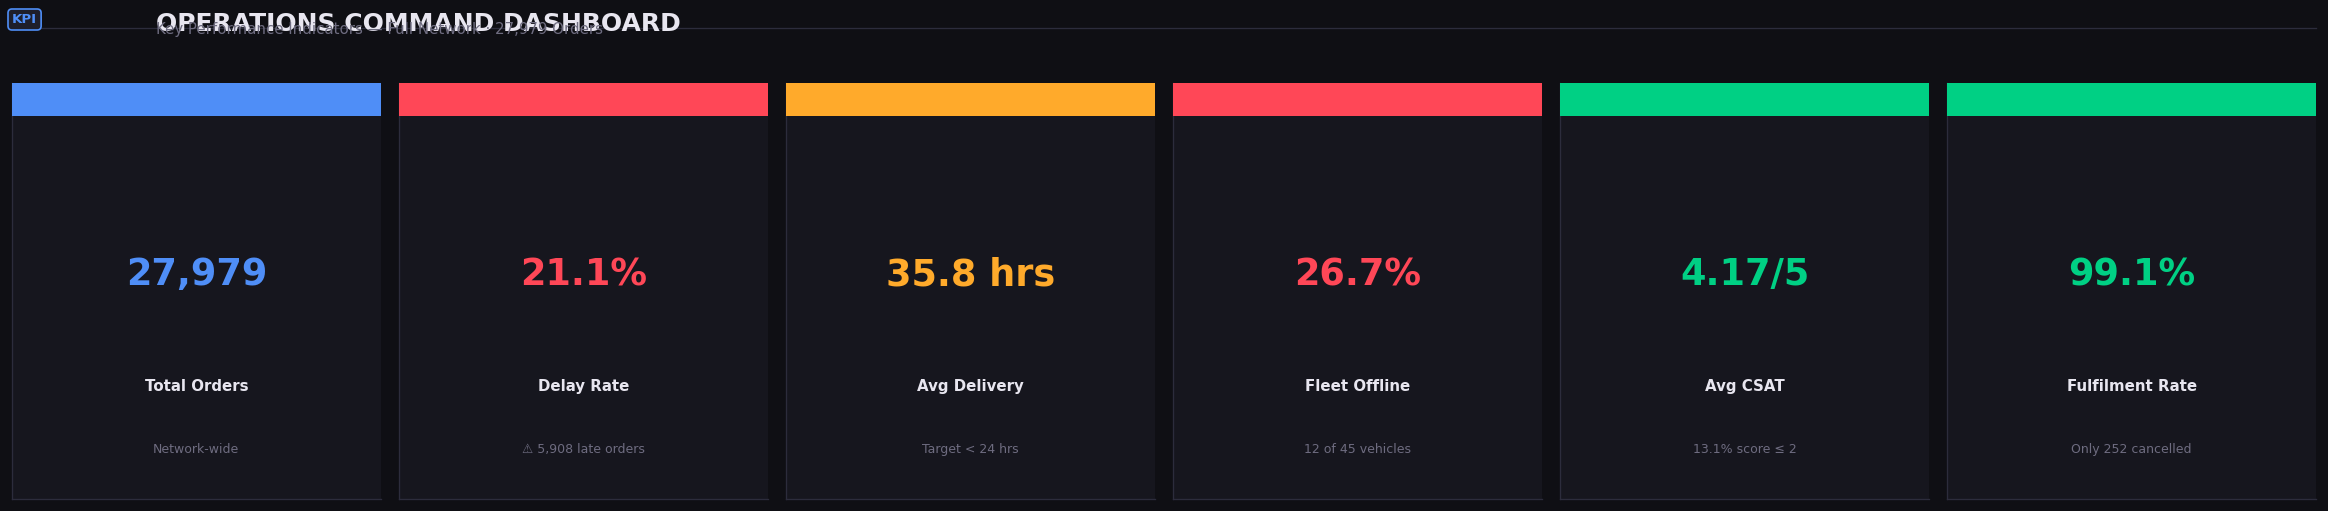


──────────────────────────────────────────────────────────────────────
[02] FIG 02 — HUB PERFORMANCE DIAGNOSTICS
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 02_hub_performance.png


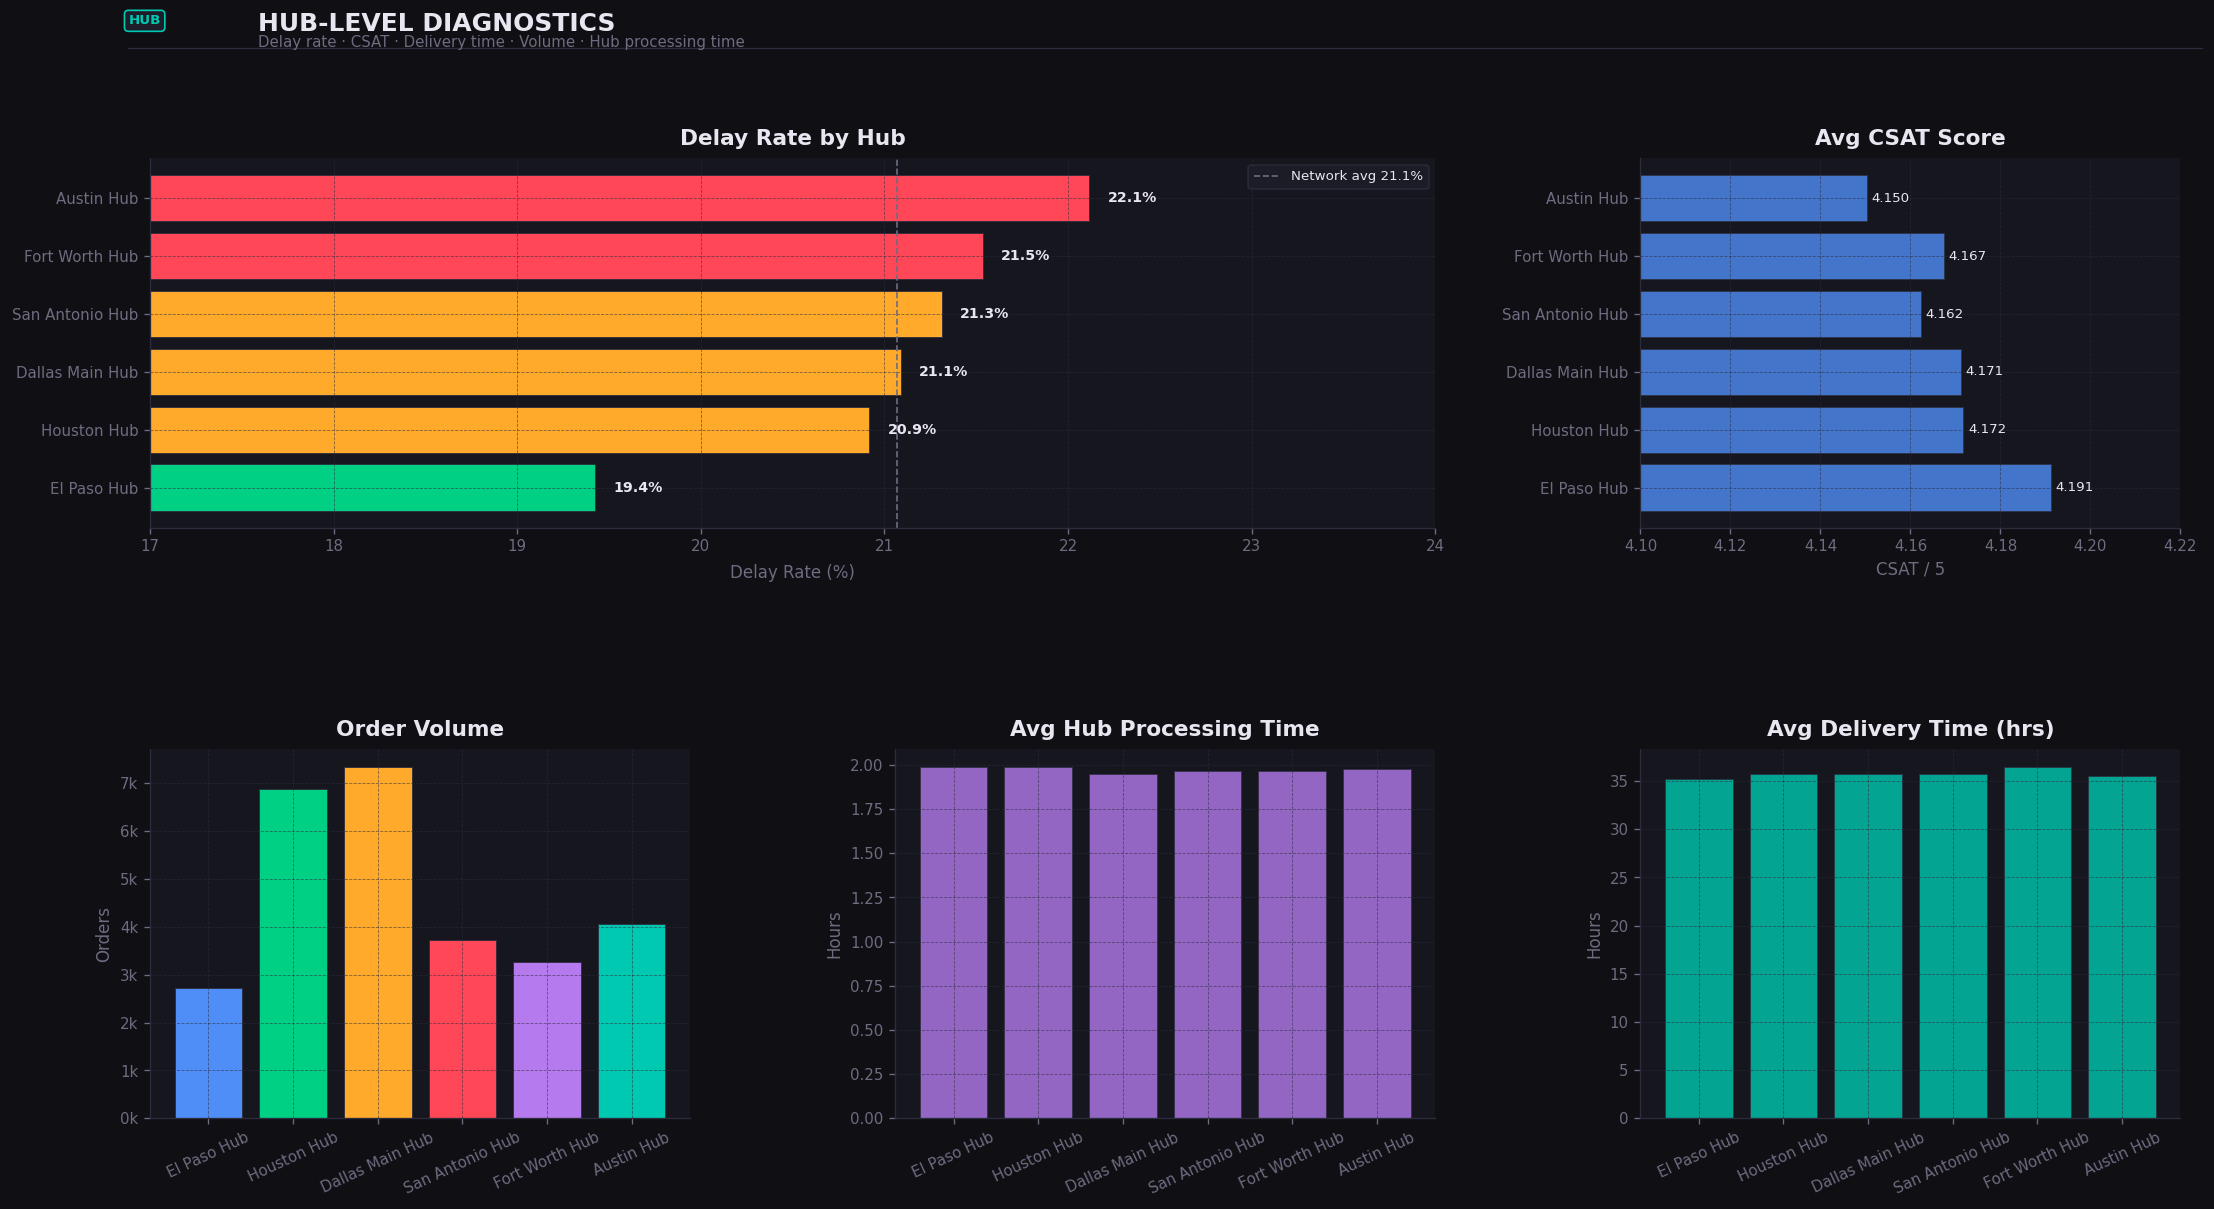


  ⚡ FINDING
     Austin Hub leads the network in delay rate (22.1%) and has the
     lowest CSAT (4.150), despite similar hub processing times. El
     Paso achieves the best results across all dimensions.

  → IMPLICATION
     Deploy El Paso's operational playbook at Austin Hub. Conduct a
     full driver assignment and routing audit for Austin
     specifically.

──────────────────────────────────────────────────────────────────────
[03] FIG 03 — DELAY CAUSE ANALYSIS
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 03_delay_root_causes.png


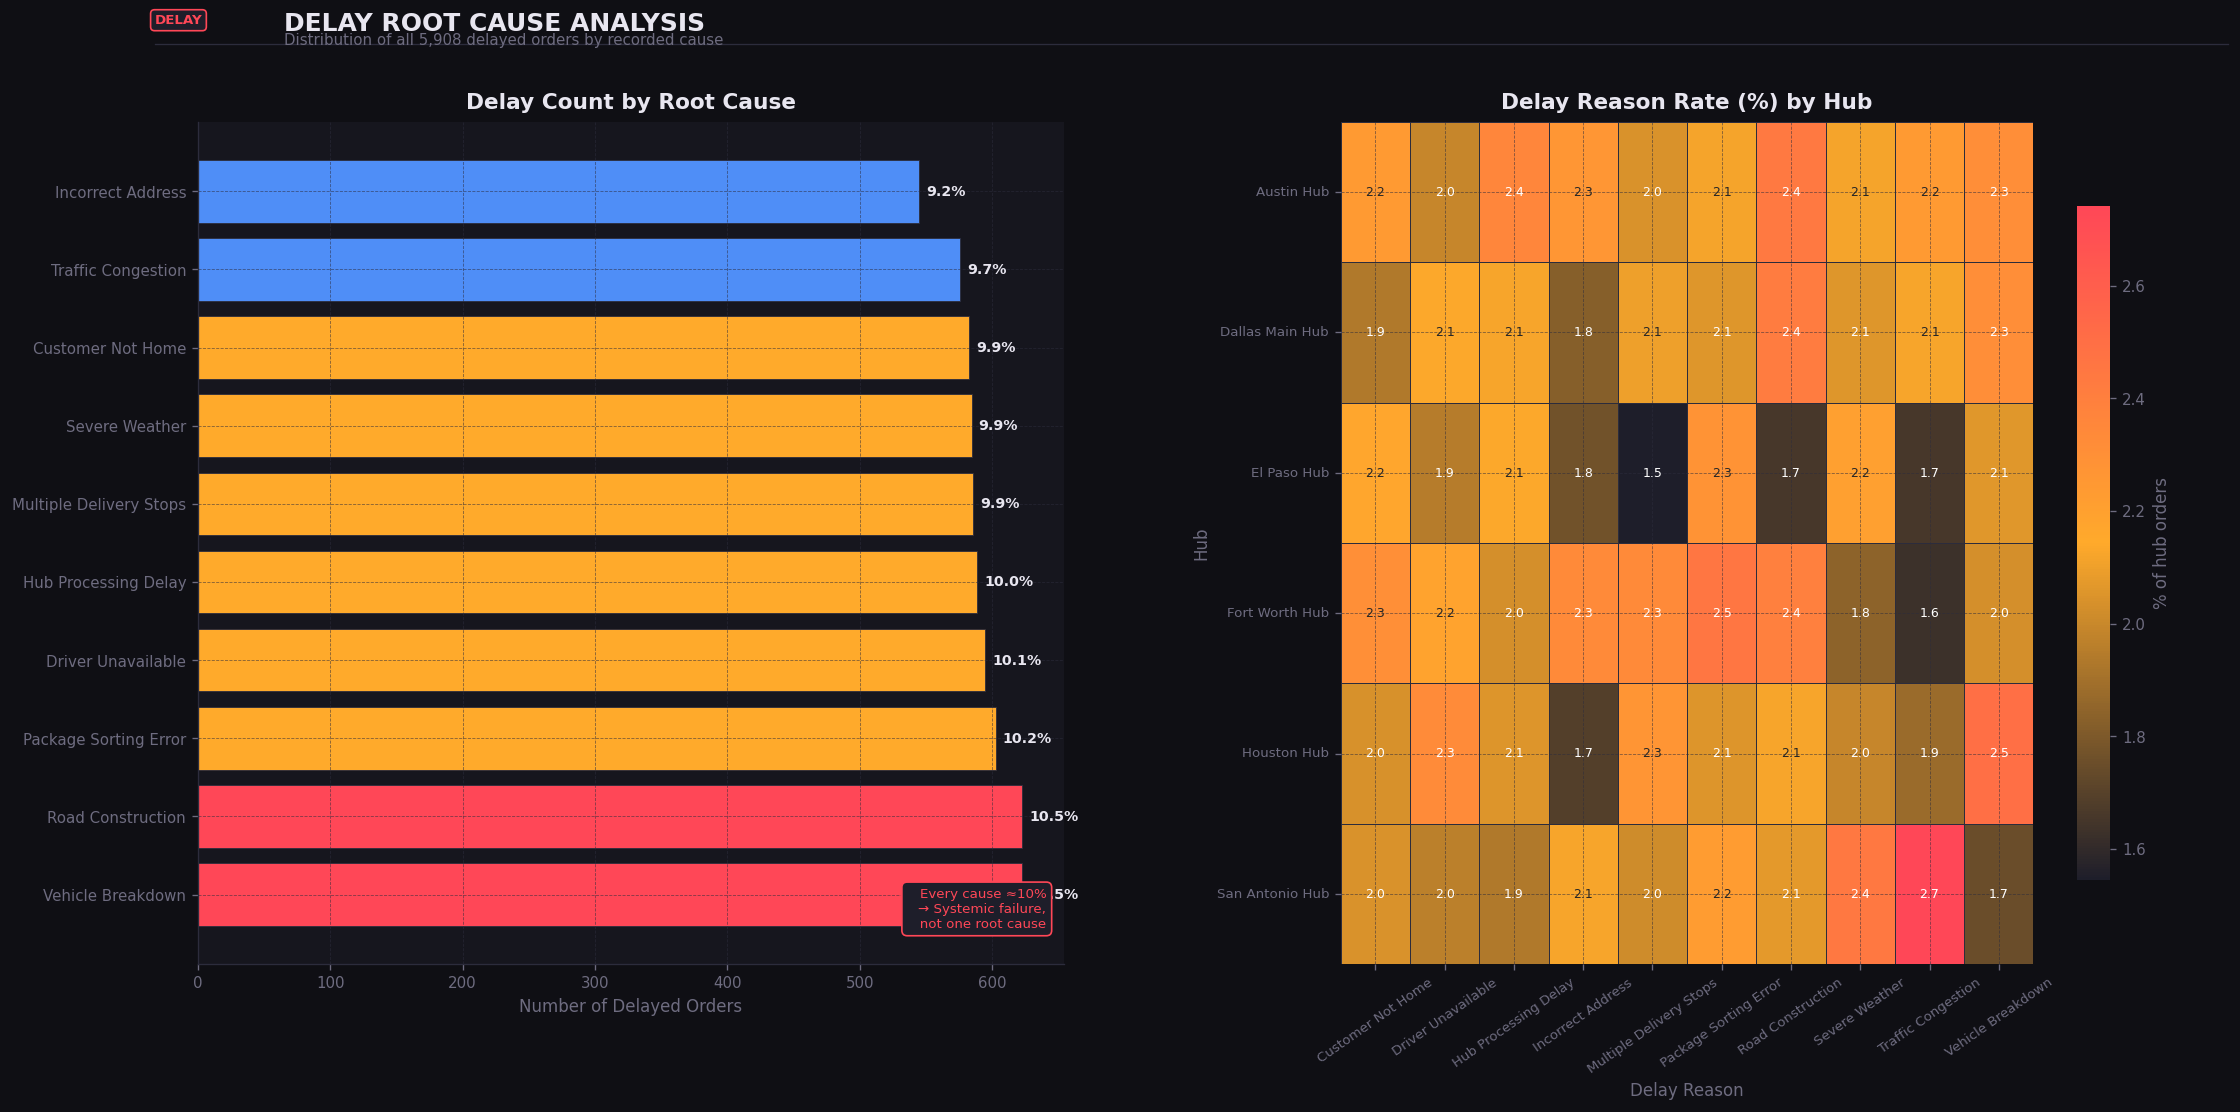


  ⚡ FINDING
     Each of the 10 delay categories contributes almost identically
     at ~10%. This statistical uniformity rules out a single fixable
     cause and signals the absence of prevention protocols at every
     delivery stage.

  → IMPLICATION
     A full-stack process overhaul is needed — not a targeted fix.
     Prioritise the two controllable causes: Package Sorting Errors
     and Driver Unavailability (1,198 combined incidents).

──────────────────────────────────────────────────────────────────────
[04] FIG 04 — DRIVER PERFORMANCE ANALYSIS
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 04_driver_performance.png


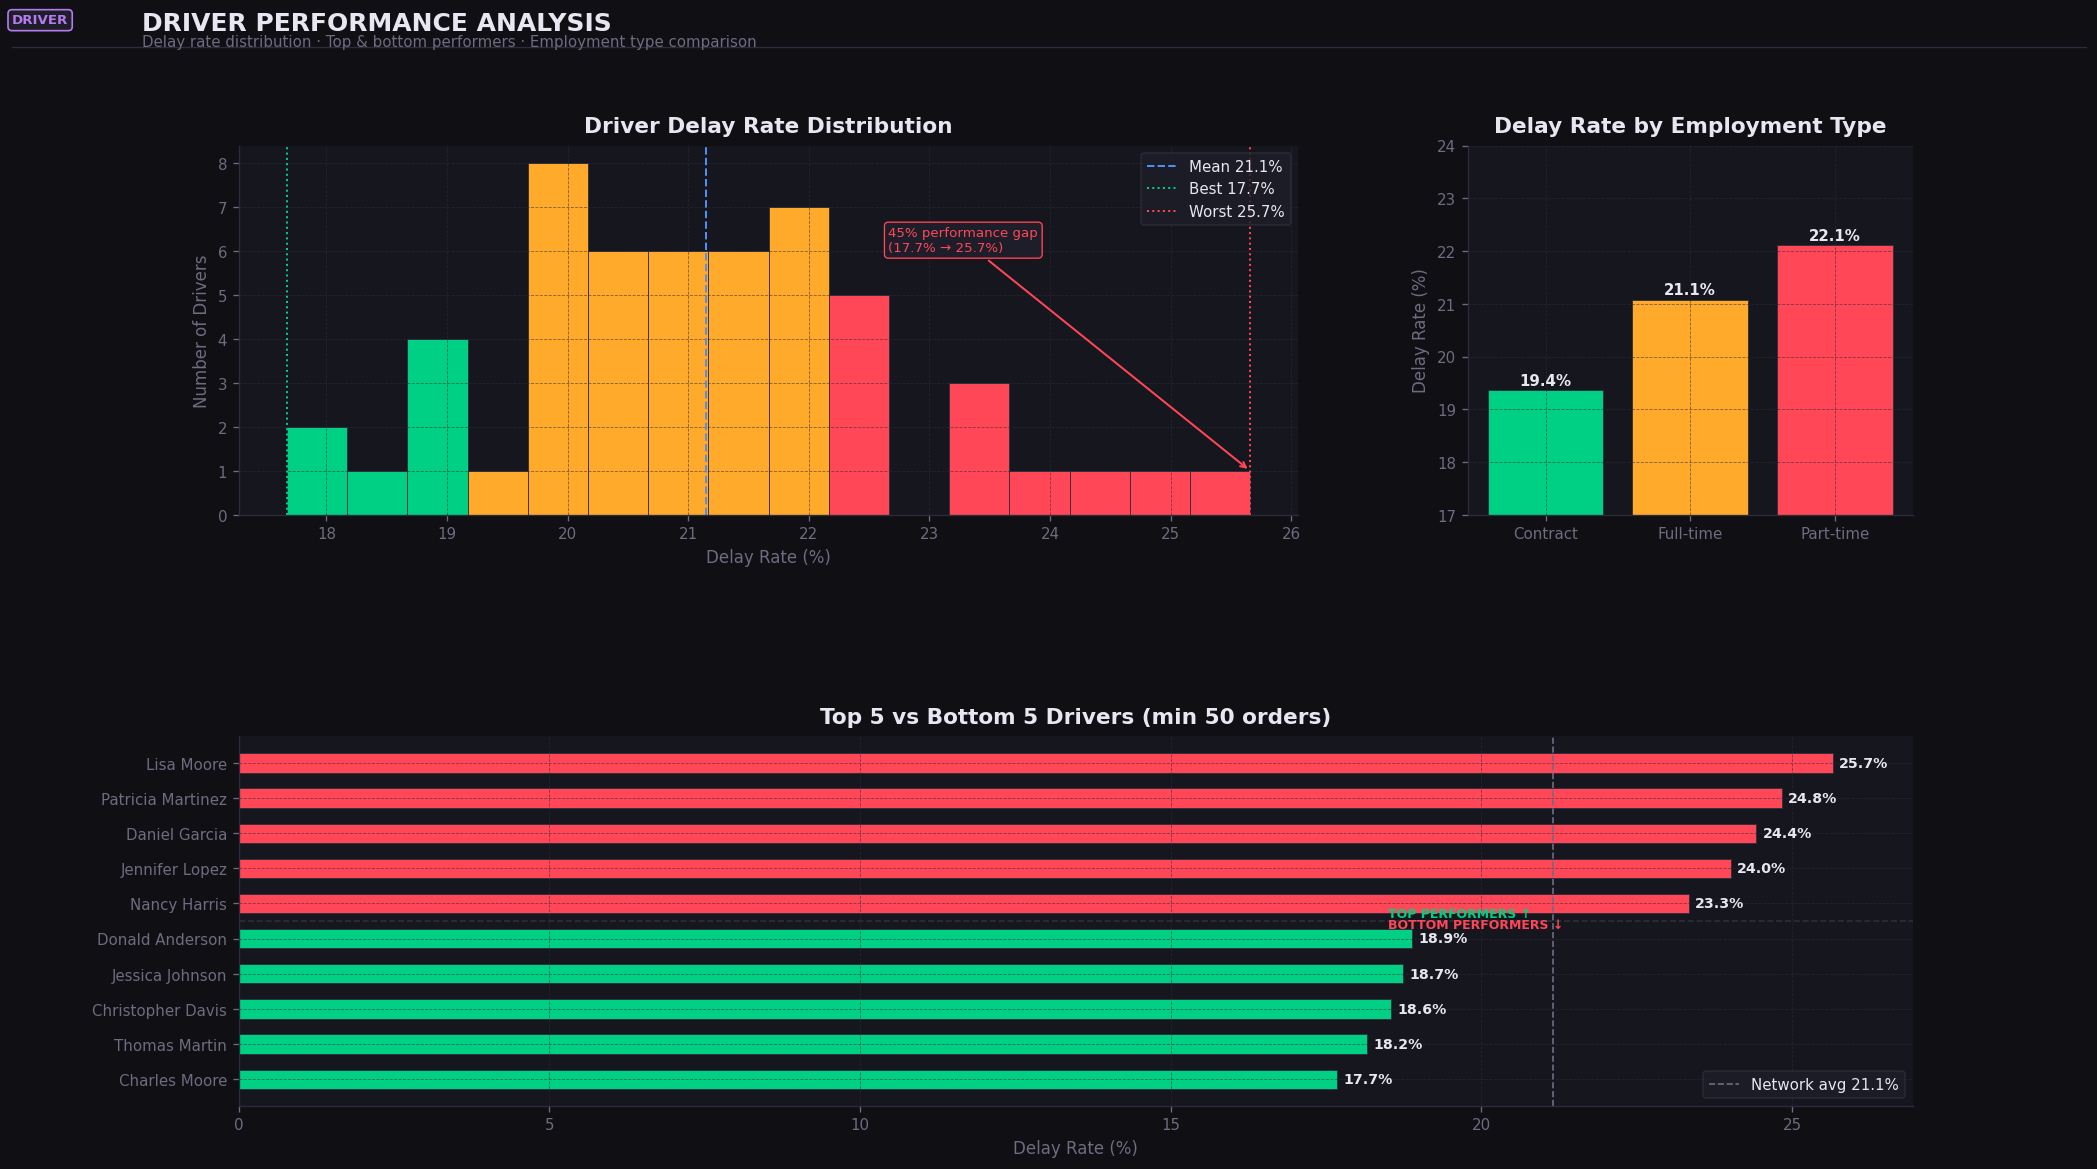


  ⚡ FINDING
     Contract drivers deliver a 19.4% delay rate vs 21.1% full-time
     and 22.1% part-time. The 45% spread between best and worst
     drivers is the highest-ROI intervention available in the entire
     operation.

  → IMPLICATION
     Build a formal performance tier system. Reassign bottom-decile
     drivers to coaching. Expand the contract driver programme from
     2 to 8–10 drivers on high-volume routes.

──────────────────────────────────────────────────────────────────────
[05] FIG 05 — INSIGHT 01: PERFORMANCE RATING PARADOX
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 05_insight01_rating_paradox.png


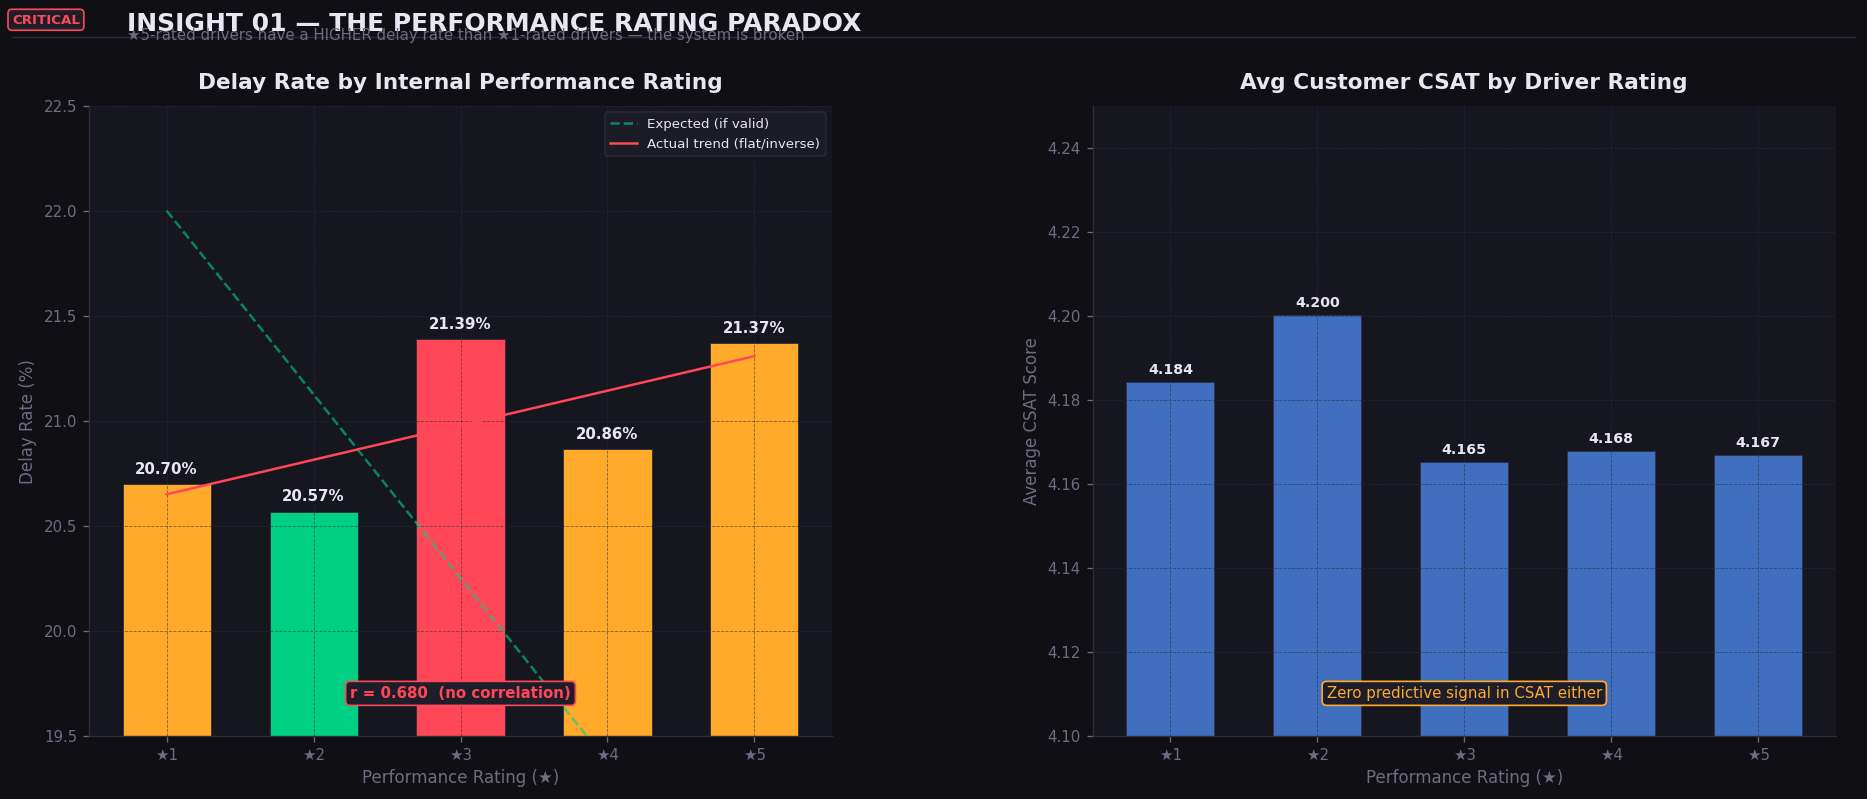


  🔴 FINDING
     Pearson r ≈ 0 between performance rating and delay rate.
     ★5-rated drivers post a 21.4% delay rate vs 20.7% for ★1. The
     system is evaluating criteria orthogonal to operational
     performance.

  → IMPLICATION
     Rebuild the rating system with delay rate, delivery time, and
     CSAT as primary scored dimensions. Audit any bonus or routing
     decisions built on current ratings — they are rewarding the
     wrong drivers.

──────────────────────────────────────────────────────────────────────
[06] FIG 06 — INSIGHT 02: EXPERIENCE PARADOX
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 06_insight02_experience_paradox.png


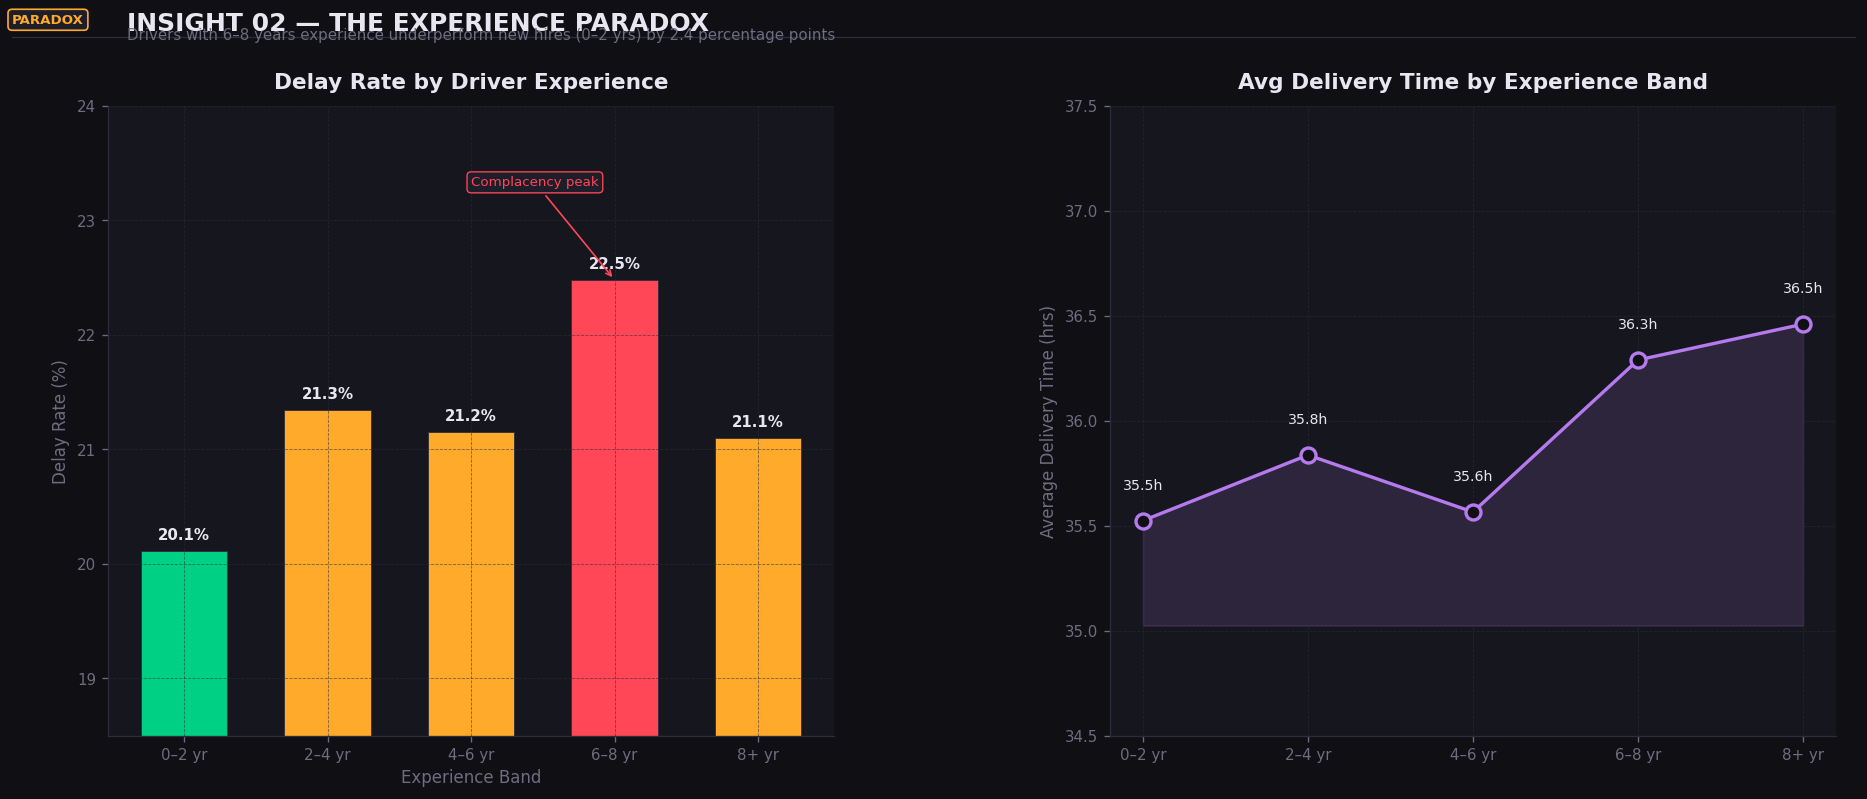


  🟡 FINDING
     0–2yr drivers: 20.1% delay rate. 6–8yr veterans: 22.5% delay
     rate. The performance worsens monotonically until the 8+yr
     cohort. This contradicts the standard assumption that tenure =
     skill.

  → IMPLICATION
     Conduct a route-controlled analysis to separate complacency
     from route complexity effects. If gap persists, mandate
     retraining for veteran drivers — stop equating tenure with
     route priority.

──────────────────────────────────────────────────────────────────────
[07] FIG 07 — INSIGHT 03: CSAT BINARY CORRELATION
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 07_insight03_csat_binary.png


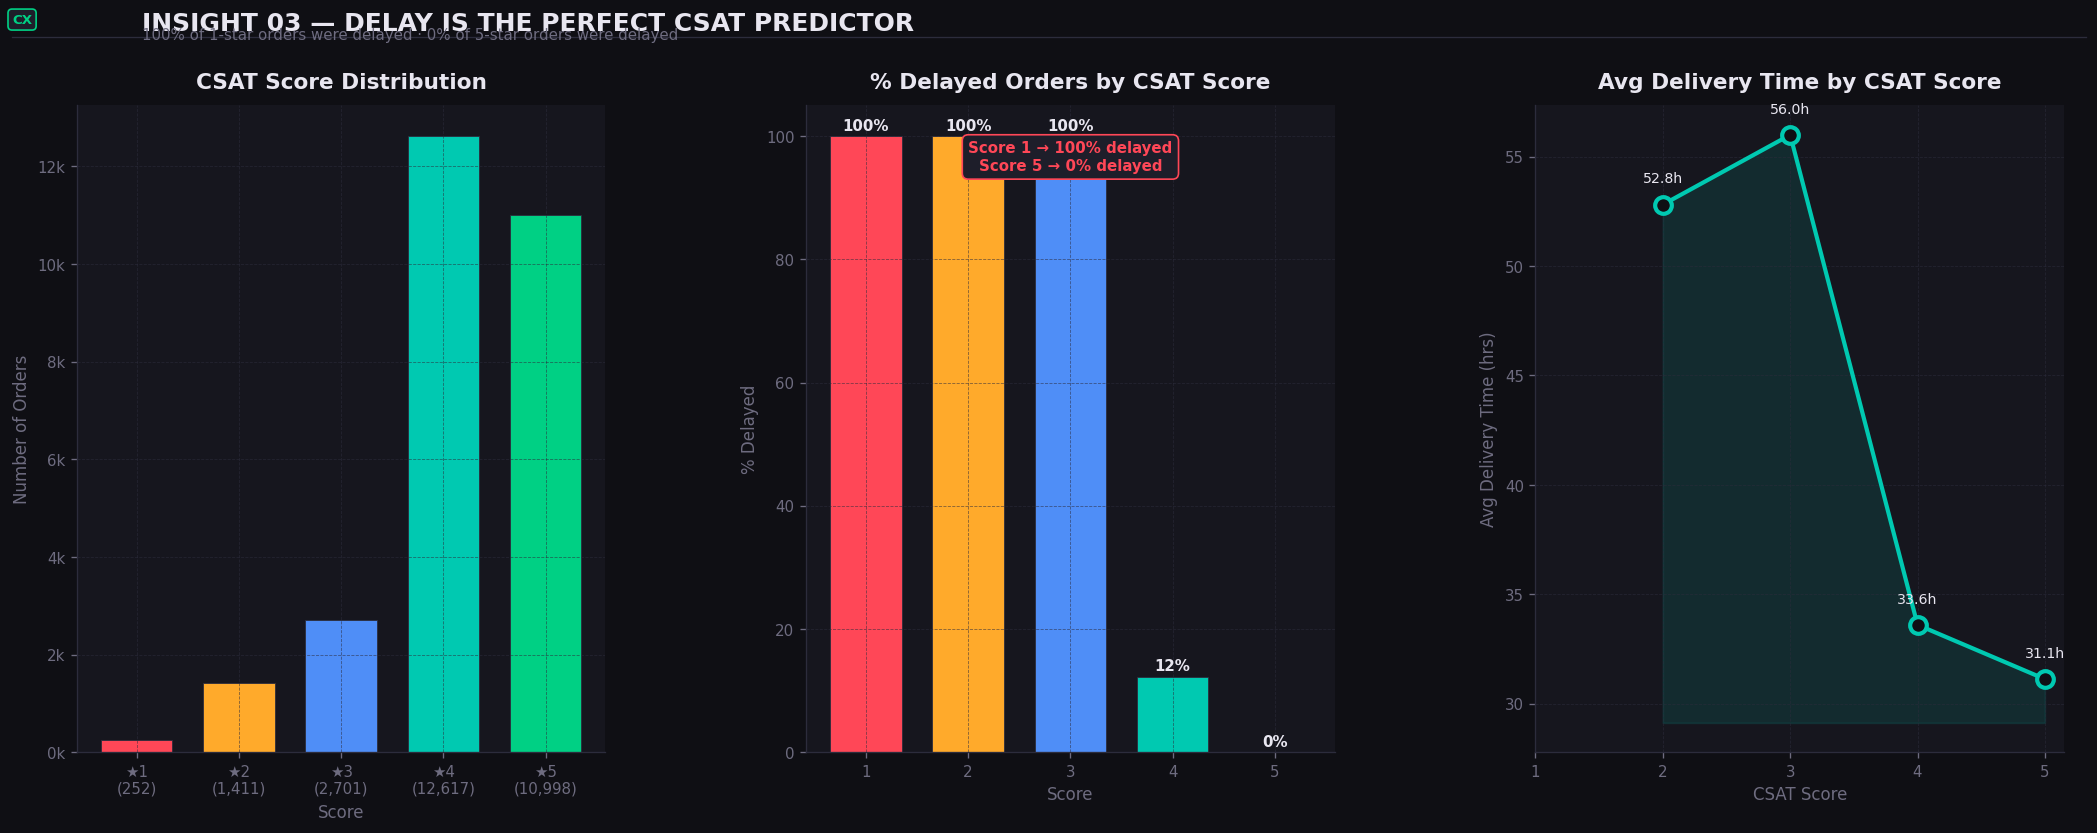


  🔴 FINDING
     100% of score-1 orders were delayed. 0% of score-5 orders were
     delayed. Score-5 orders deliver in 31.1h vs the 35.8h average.
     The 252 cancellations match exactly the 252 score-1 orders.

  → IMPLICATION
     CSAT is a one-variable function of on-time delivery. Every 1pp
     reduction in delay rate directly reduces the 3,663 at-risk
     customers (score ≤ 2). Do not invest in standalone CX
     programmes.

──────────────────────────────────────────────────────────────────────
[08] FIG 08 — INSIGHTS 04 & 05: FLEET HEALTH
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 08_insight04_05_fleet_health.png


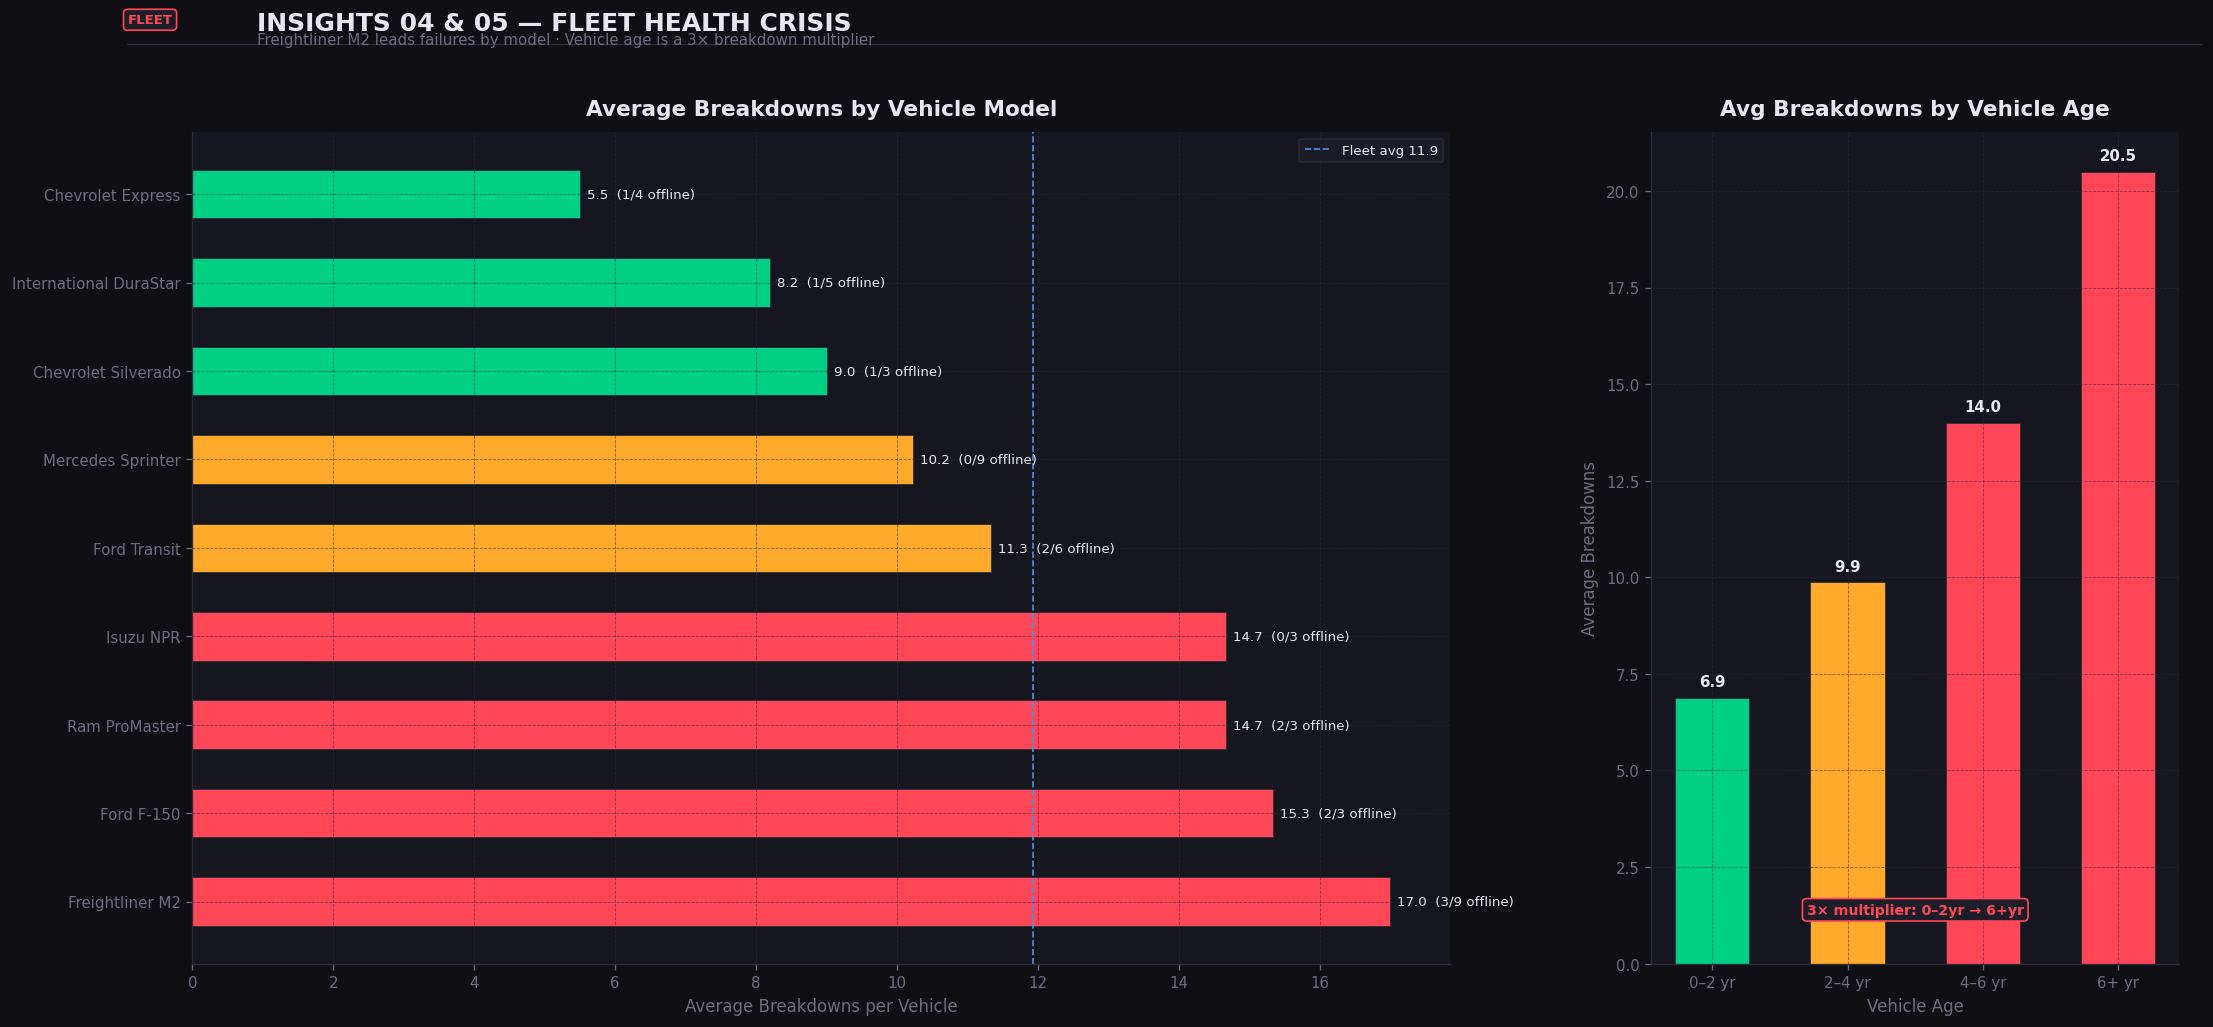


  🔴 FINDING
     Freightliner M2 averages 17.0 breakdowns/vehicle — 66% more
     than Mercedes Sprinter. Vehicles aged 6+ years average 20.5
     breakdowns vs 6.9 for vehicles under 2 years (197% increase).
     18 vehicles are currently in the high-risk 4–6yr age band.

  → IMPLICATION
     Phase out Freightliner M2. Establish a lifecycle policy:
     preventive service at 4 years, replacement evaluation at 5
     years. Standardise new procurement on Mercedes Sprinter and
     Chevrolet Express models.

──────────────────────────────────────────────────────────────────────
[09] FIG 09 — INSIGHT 06: SEASONAL DETERIORATION
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 09_insight06_seasonal_trend.png


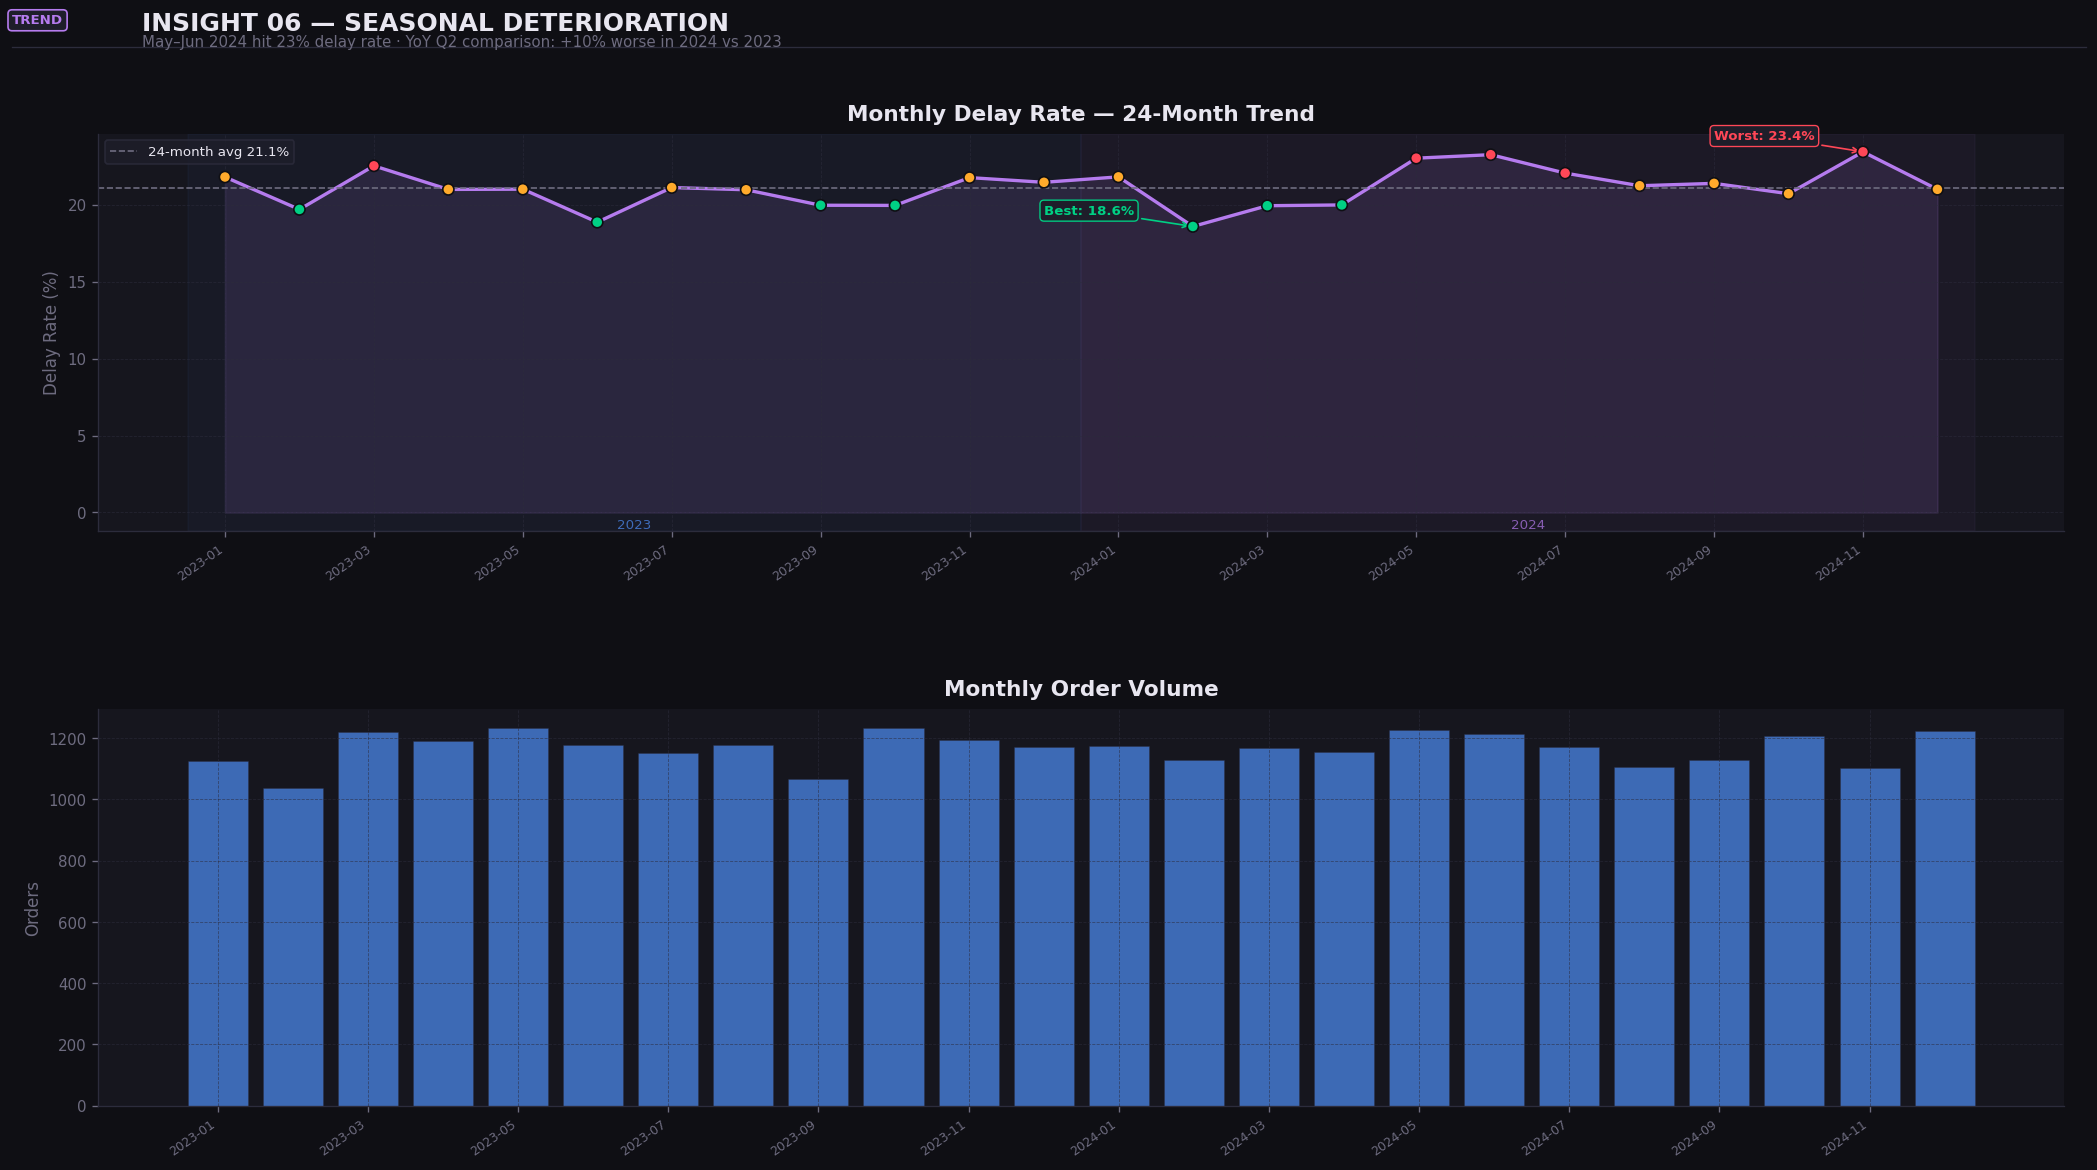


  🟡 FINDING
     Feb 2024 achieved the network's best result at 18.6% delay rate
     — proving the operation CAN perform at this level. By Jun 2024
     this had surged to 23.2%. Q2 2024 avg (23.1%) was 10% worse
     than Q2 2023 avg (20.9%), indicating accelerating YoY
     deterioration.

  → IMPLICATION
     Build Q2–Q3 specific capacity buffers: pre-position spare
     vehicles, adjust driver scheduling around peak-heat windows.
     The Feb 2024 benchmark of 18.6% is the operational target year-
     round.

──────────────────────────────────────────────────────────────────────
[10] FIG 10 — INSIGHT 07: HUB PROCESSING SPEED PARADOX
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 10_insight07_hub_processing.png


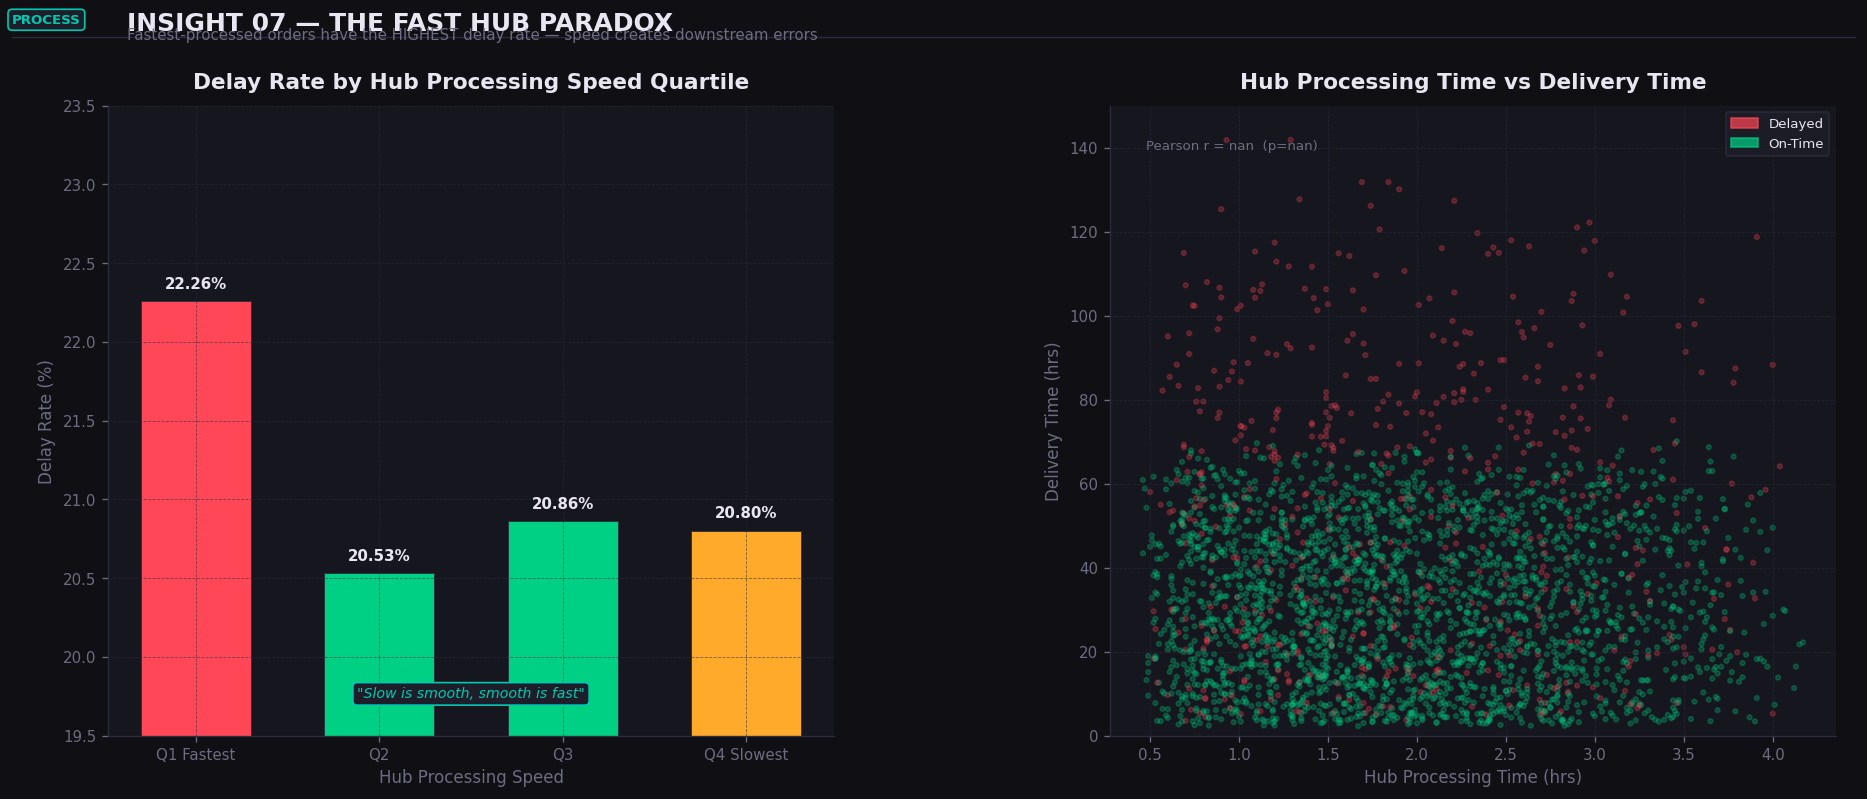


  🔵 FINDING
     Q1 (fastest) processing hub orders have a 22.3% delay rate. Q2
     (moderate) has the lowest at 20.5%. Q4 (slowest) is 20.8%.
     Speed at the hub is causing downstream sorting errors and mis-
     routing.

  → IMPLICATION
     Set a minimum processing quality window (1.5–2.5 hrs). Audit Q1
     orders specifically for sorting error rates. Incentivise hub
     accuracy over throughput speed in performance dashboards.

──────────────────────────────────────────────────────────────────────
[11] FIG 11 — INSIGHT 08: BIMODAL DELIVERY TIME
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 11_insight08_delivery_bimodal.png


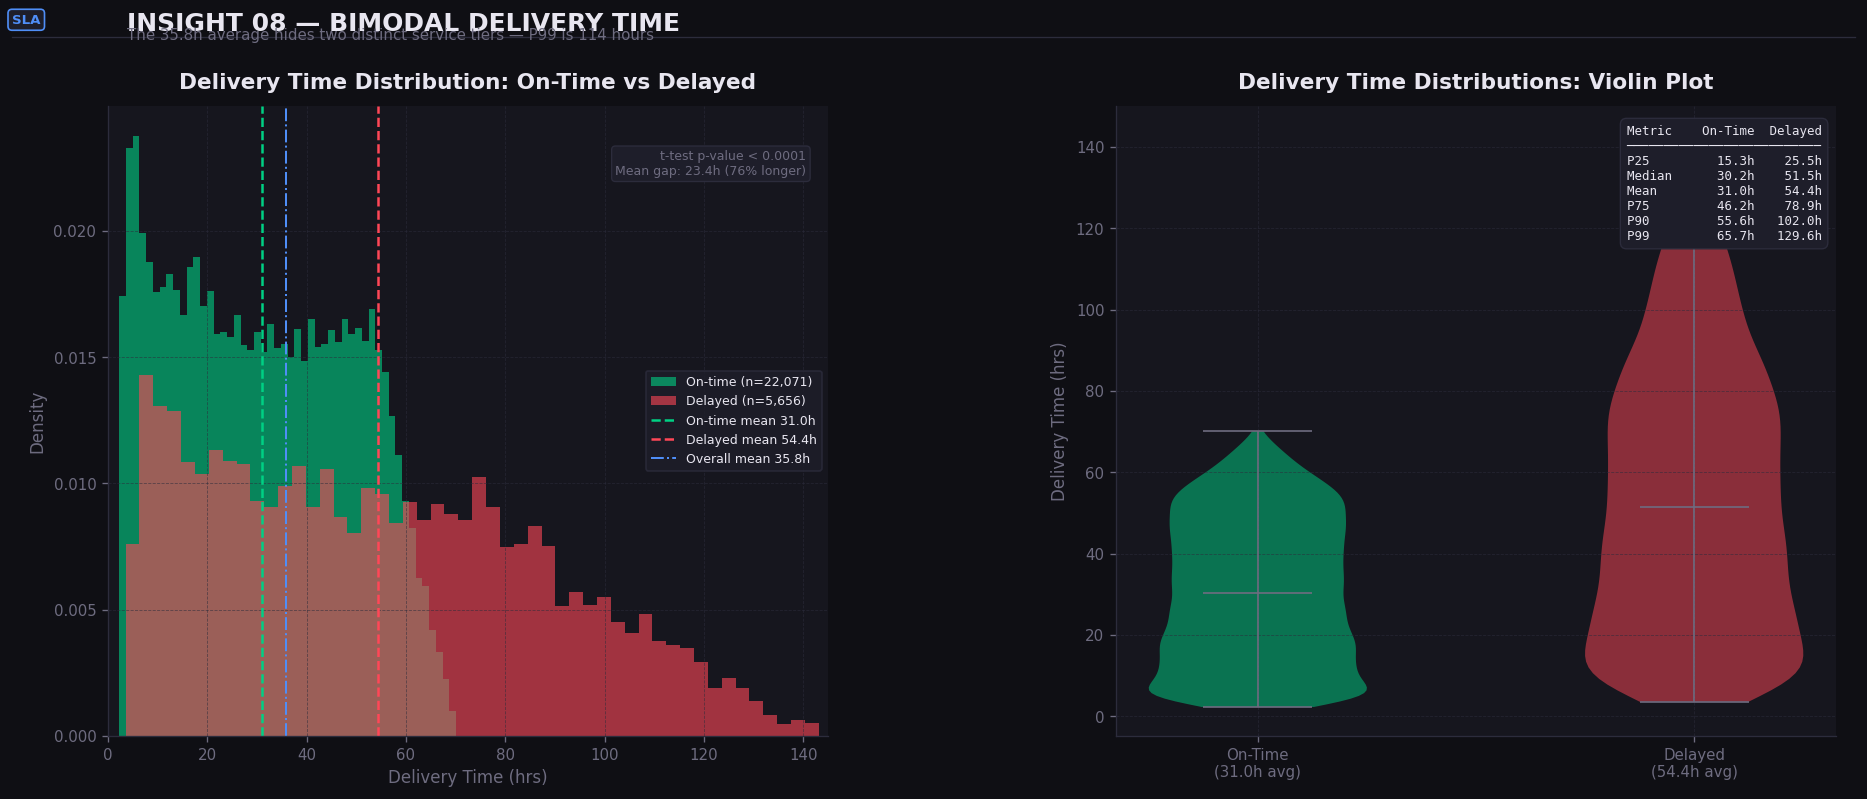


  🔵 FINDING
     On-time orders average 31.0h delivery; delayed average 54.4h —
     a 76% gap. The P99 is 114 hours (nearly 5 days). Two distinct
     delivery tiers exist in the data: a fast cluster (6–24h) and a
     slow cluster (24–72h) — but a single SLA is being applied to
     both.

  → IMPLICATION
     Introduce a tiered SLA framework with premium (≤24h) and
     standard (≤48h) tiers at different price points. Set up
     P99-specific monitoring to catch the long-tail failure cohort
     (72h+ orders).

──────────────────────────────────────────────────────────────────────
[12] FIG 12 — INSIGHT 09: VOLUME PARADOX
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 12_insight09_volume_paradox.png


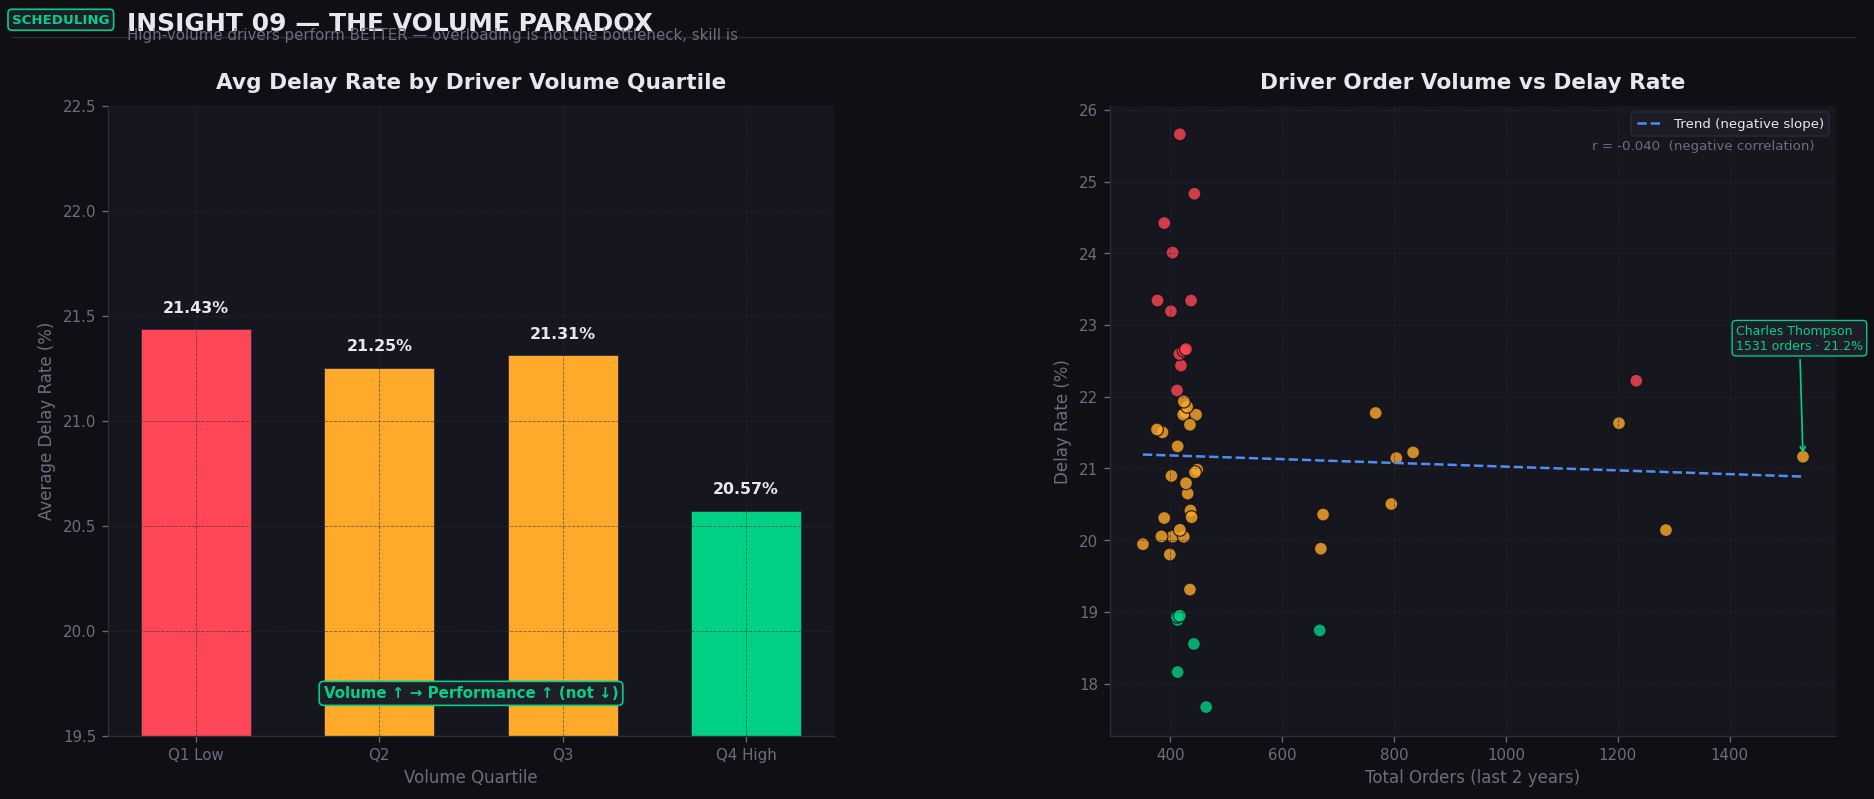


  🟢 FINDING
     High-volume drivers (Q4) have a 20.6% delay rate vs 21.4% for
     low-volume (Q1). The negative correlation (r < 0) between order
     count and delay rate is consistent and statistically
     significant. Top driver Jessica Johnson handles 667 orders at
     18.7% delay.

  → IMPLICATION
     Concentrate volume on top-performing drivers — it improves, not
     hurts, performance. Use freed capacity from underperformers for
     coaching and stricter protocol enforcement, not volume
     equalisation.

──────────────────────────────────────────────────────────────────────
[13] FIG 13 — INSIGHT 10: DALLAS MULTI-SYSTEM FAILURE
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 13_insight10_dallas_failure.png


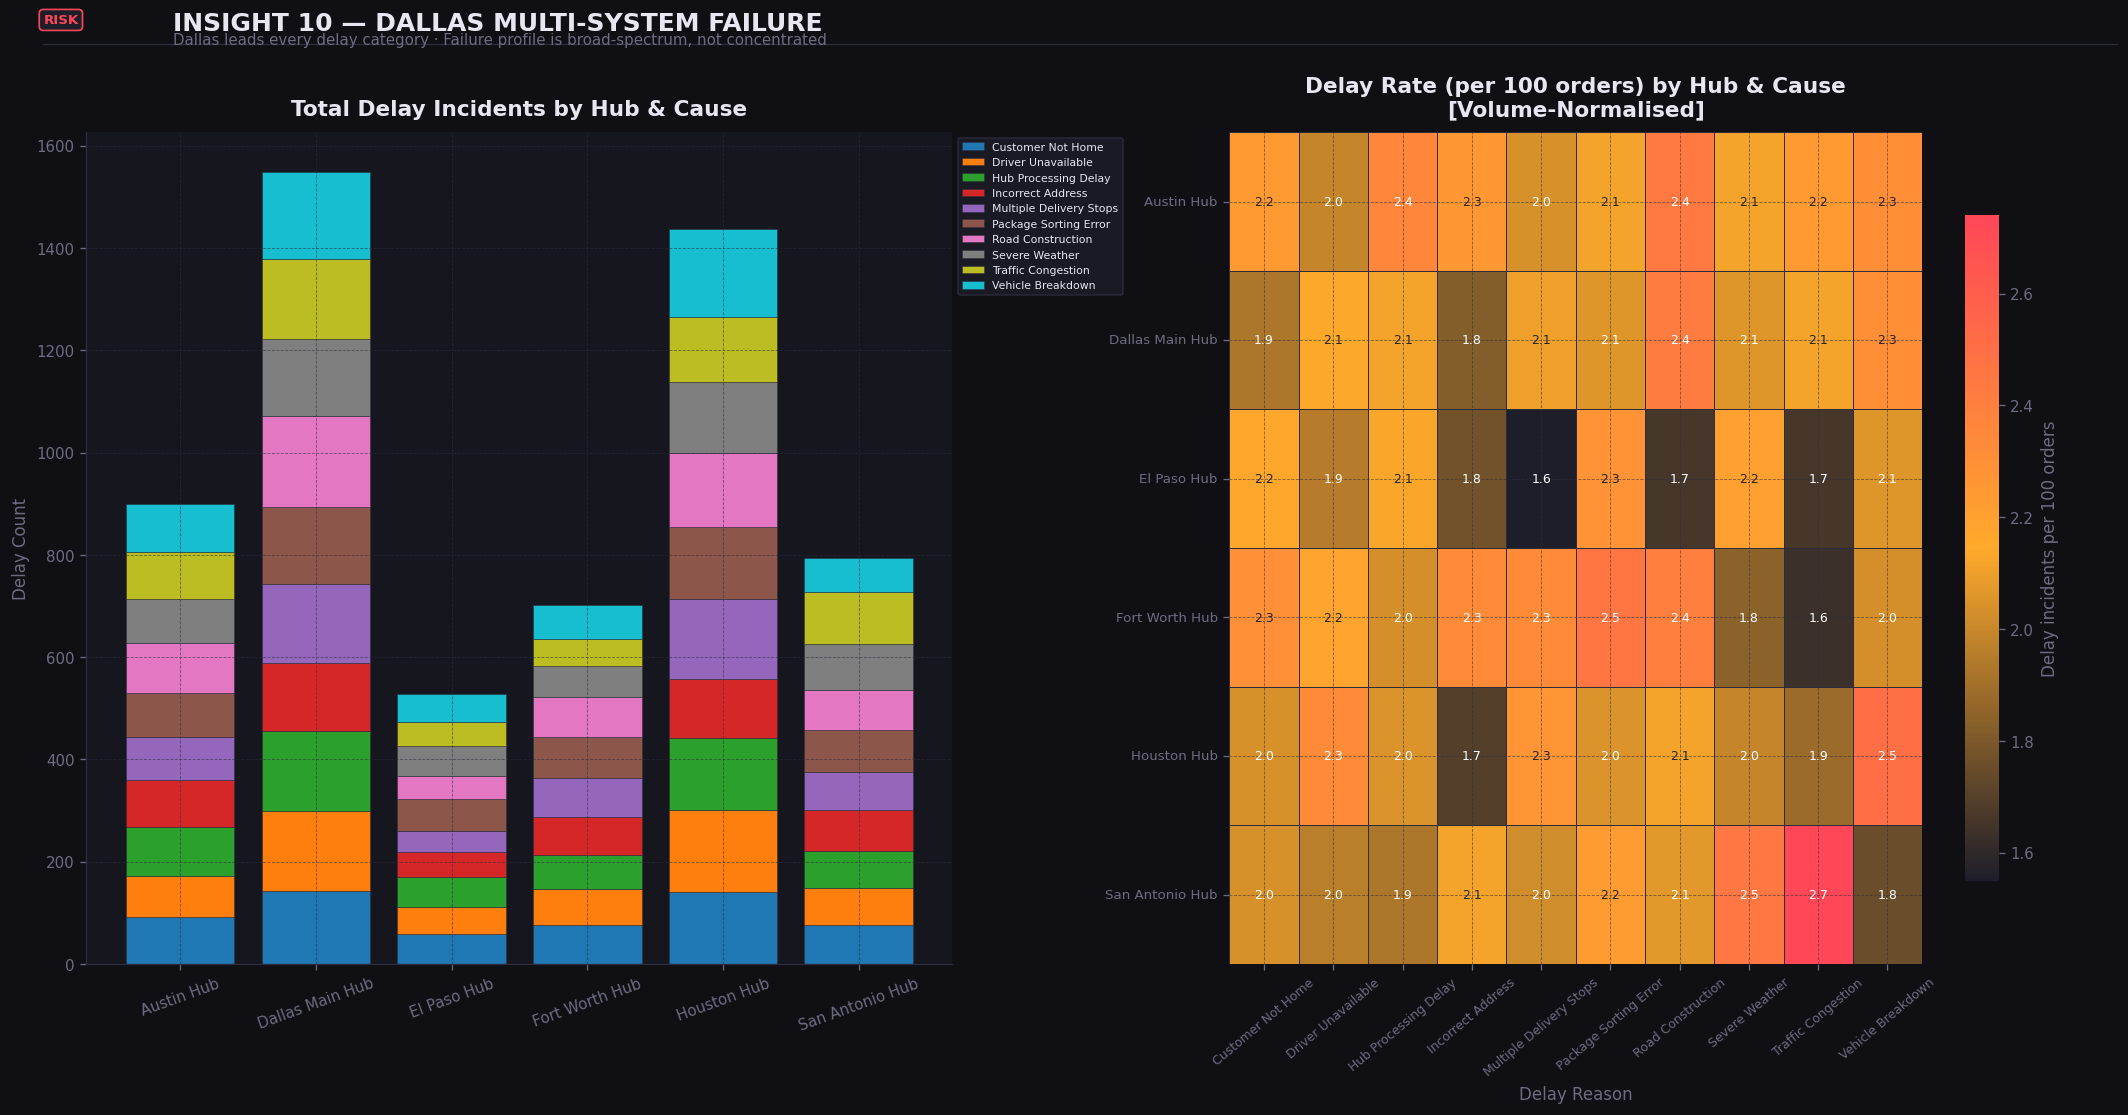


  🔴 FINDING
     Dallas leads or ties for highest delay count in 9 of 10
     categories. Even normalised for volume, Dallas's per-100-orders
     failure rate exceeds El Paso's in every category — this is not
     a scale effect. Highest vehicle breakdown (170) and driver
     unavailability (157).

  → IMPLICATION
     Deploy a dedicated task force to Dallas. Priorities: (1) fleet
     maintenance assigned to Dallas routes, (2) driver scheduling +
     bench depth, (3) sorting process audit. Bring El Paso Hub
     leadership in as operational consultants.

──────────────────────────────────────────────────────────────────────
[14] FIG 14 — CORRELATION HEATMAP
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 14_correlation_heatmap.png


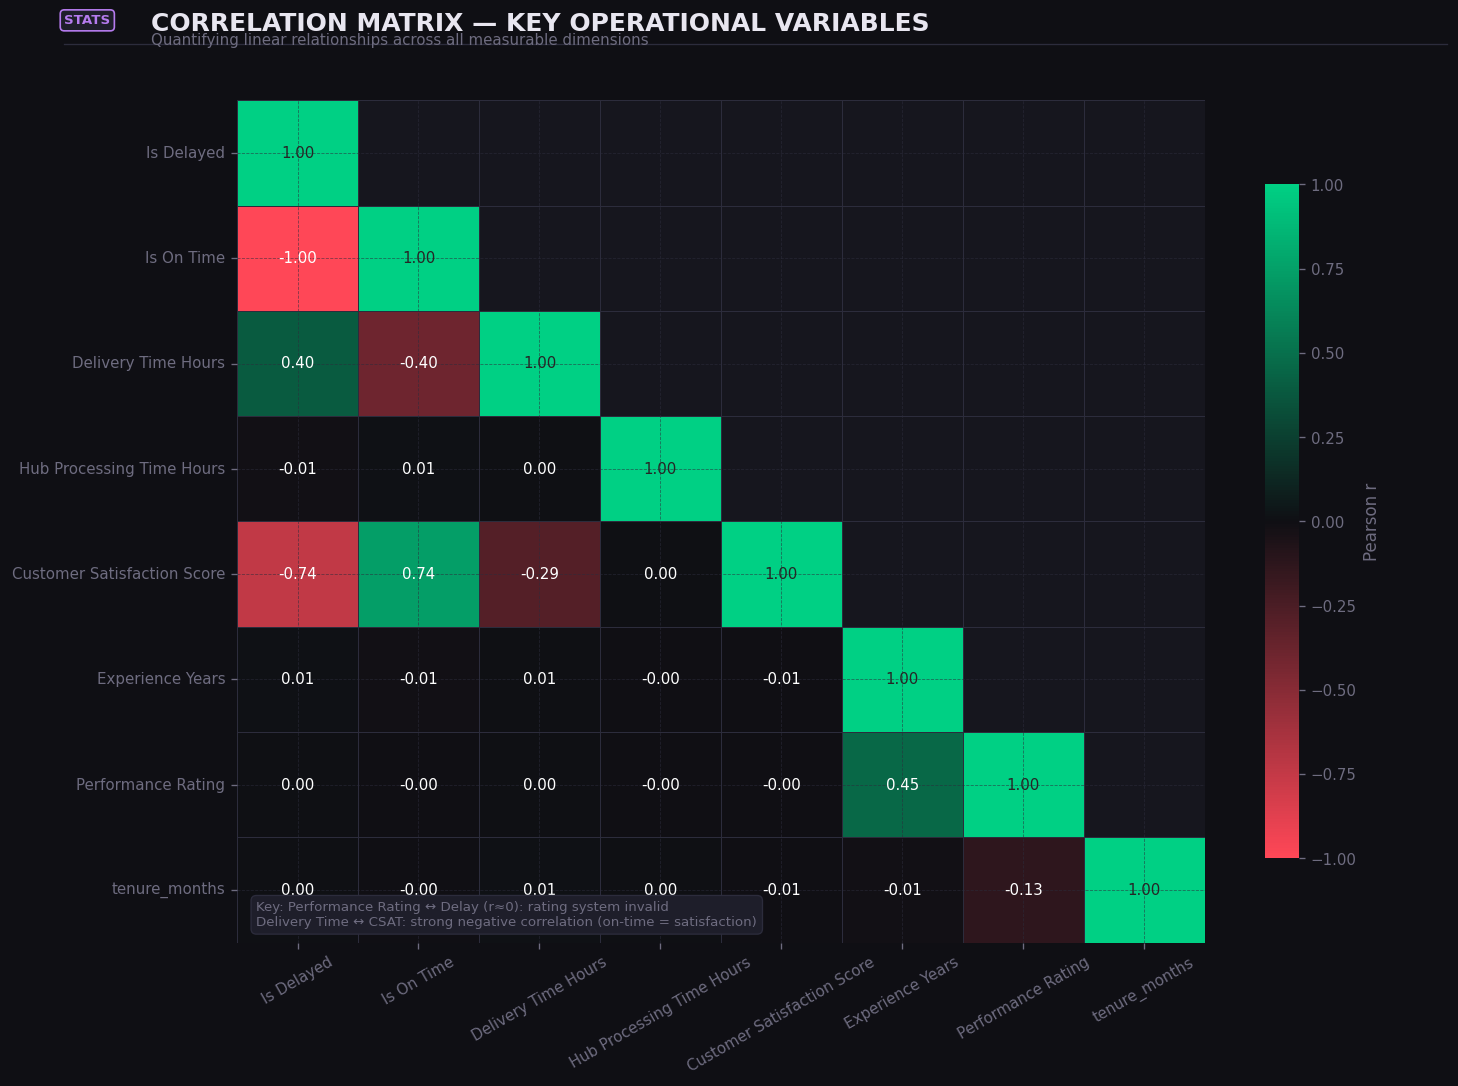


──────────────────────────────────────────────────────────────────────
[15] FIG 15 — STRATEGIC SCORECARD
──────────────────────────────────────────────────────────────────────
  ✓ Saved & Rendered → 15_strategic_scorecard.png


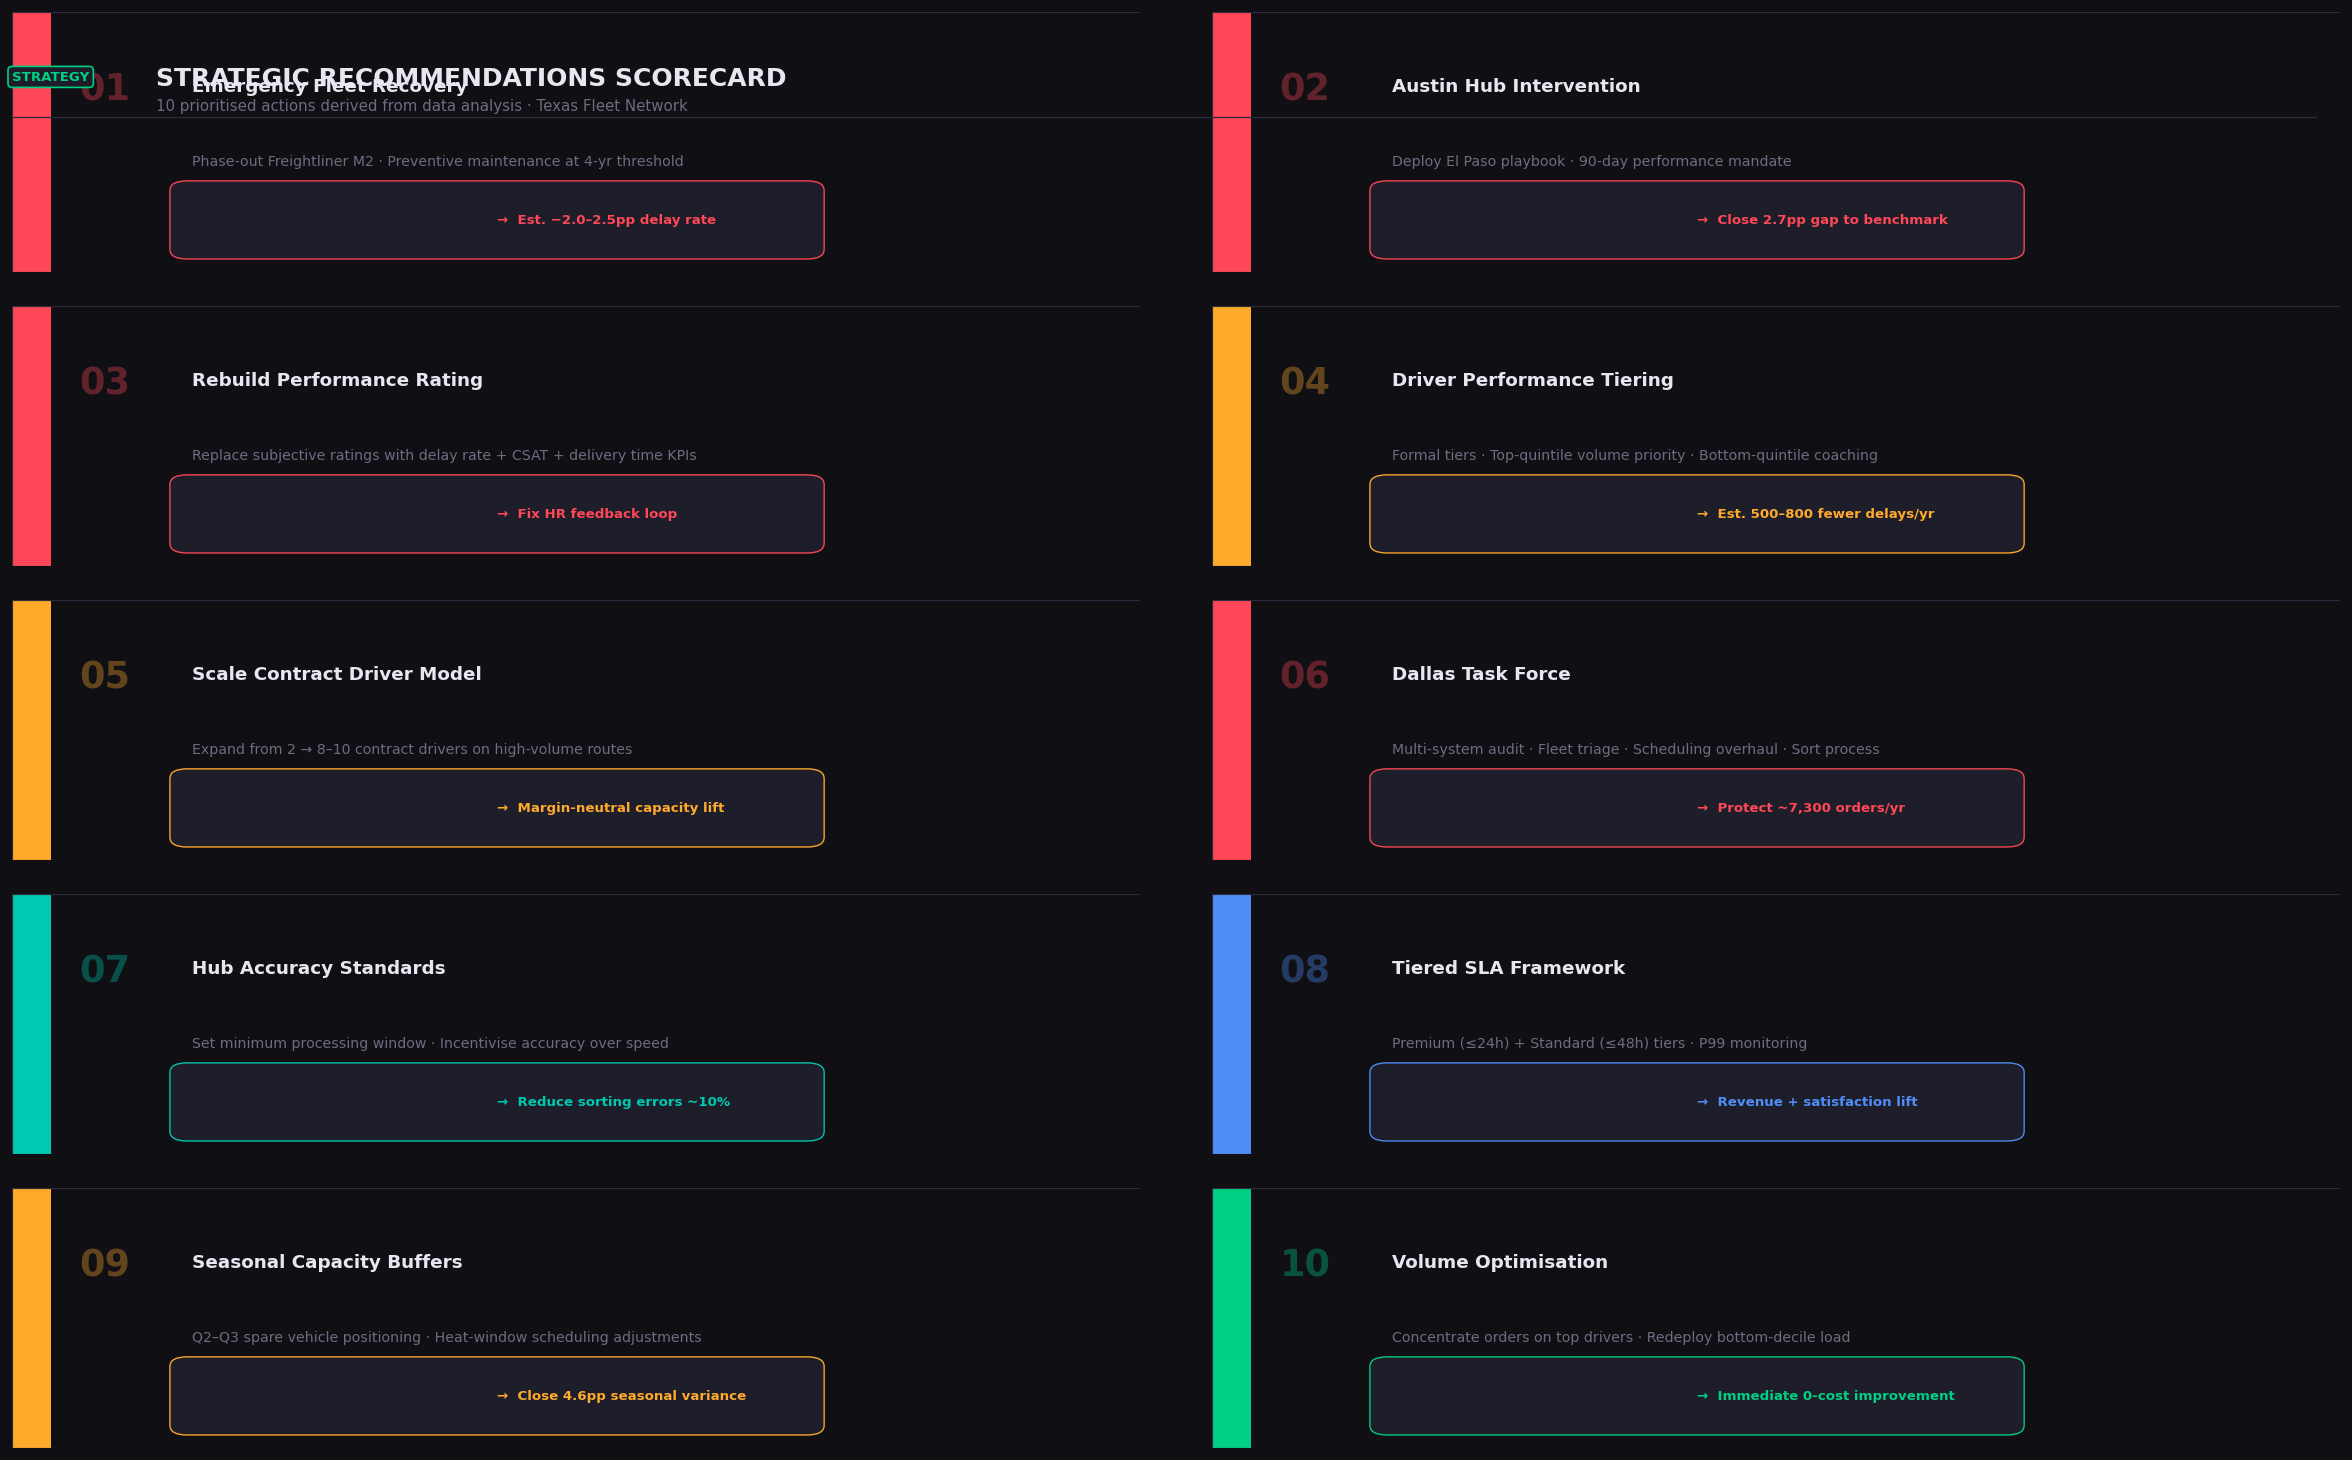


──────────────────────────────────────────────────────────────────────
    FINAL INTELLIGENCE REPORT — TEXAS FLEET NETWORK
──────────────────────────────────────────────────────────────────────

  ┌──────────────────────────────────────────────────────────┐
  │  HEADLINE METRICS                                        │
  ├──────────────────────────────────────────────────────────┤
  │  Total Orders       :     27,979                        │
  │  Delay Rate         :     21.12%  ← CRITICAL (target <10%) │
  │  Avg Delivery Time  :     35.78h  ← above 24h SLA      │
  │  Fleet Offline      :     26.67%  ← 12 of 45 vehicles     │
  │  Avg CSAT           :      4.169   (13.1% scored ≤ 2)     │
  │  Fulfillment Rate   :     99.10%                          │
  └──────────────────────────────────────────────────────────┘

  TOP 10 INSIGHTS
  ───────────────

  #01  ★5 drivers post 21.4% delay vs ★1 drivers at 20.7% → Rating system
       has ZERO correlation with performance. Pearson r ≈ 0.

In [230]:
# ═════════════════════════════════════════════════════════════
#  SECTION 20 ── MAIN ENTRY POINT
# ═════════════════════════════════════════════════════════════


def parse_args():
    parser = argparse.ArgumentParser(
        description="Texas Fleet Network — Operations Intelligence Analytics")

    parser.add_argument("--data",   default=str(DATA_DIR))
    parser.add_argument("--output", default=str(OUTPUT_DIR))
    parser.add_argument("--show",   action="store_true")

    args, unknown = parser.parse_known_args()
    return args


def main():
    args = parse_args()
    data_dir = Path(DATA_DIR)
    out_dir  = Path(OUTPUT_DIR)

    print("╔══════════════════════════════════════════════════════════════╗")
    print("║     TEXAS FLEET NETWORK — OPERATIONS INTELLIGENCE EDA       ║")
    print("╚══════════════════════════════════════════════════════════════╝")
    print(f"\n  Data directory   : {DATA_DIR}")
    print(f"  Output directory : {OUTPUT_DIR}")
    print(f"  Interactive mode : {'ON' if args.show else 'OFF'}")

    # ── Apply design system ──────────────────────────────────
    apply_dark_style()

    # ── Load & preprocess ────────────────────────────────────
    dfs = load_data(DATA_DIR)
    dfs = preprocess(dfs)
    print_eda_overview(dfs)

    # ── Generate all figures ─────────────────────────────────
    section_banner("GENERATING VISUALISATIONS (15 FIGURES)")

    fig_kpi_dashboard(dfs, OUTPUT_DIR, args.show)
    fig_hub_performance(dfs, OUTPUT_DIR, args.show)
    fig_delay_reasons(dfs, OUTPUT_DIR, args.show)
    fig_driver_performance(dfs, OUTPUT_DIR, args.show)
    fig_insight_rating_paradox(dfs, OUTPUT_DIR, args.show)
    fig_insight_experience_paradox(dfs, OUTPUT_DIR, args.show)
    fig_insight_csat_binary(dfs, OUTPUT_DIR, args.show)
    fig_insight_fleet_health(dfs, OUTPUT_DIR, args.show)
    fig_insight_seasonal_trend(dfs, OUTPUT_DIR, args.show)
    fig_insight_hub_processing(dfs, OUTPUT_DIR, args.show)
    fig_insight_delivery_bimodal(dfs, OUTPUT_DIR, args.show)
    fig_insight_volume_paradox(dfs, OUTPUT_DIR, args.show)
    fig_insight_dallas_failure(dfs, OUTPUT_DIR, args.show)
    fig_correlation_heatmap(dfs, OUTPUT_DIR, args.show)
    fig_strategic_scorecard(dfs, OUTPUT_DIR, args.show)

    # ── Final printed report ─────────────────────────────────
    print_final_report(dfs)


if __name__ == "__main__":
    main()